Data Mining Project

Mohammadreza Tavafoghi : 40363031004

Shayan Etminan : 40363031002

Step 0 – Import libraries & Dataset Selection & Problem Definition

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import time
START = time.perf_counter()

Step 1 – Data Understanding & Exploratory Data Analysis (EDA)

In [2]:
df_raw = pd.read_csv('Crash_Reporting_-_Drivers_Data.csv', low_memory = False)
df_work = df_raw.copy()
# Source : https://catalog.data.gov/dataset/crash-reporting-drivers-data

In [3]:
df_work.shape

(207453, 39)

In [4]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

df_work.head()

,Report Number,Local Case Number,Agency Name,ACRS Report Type,Crash Date/Time,Route Type,Road Name,Cross-Street Name,Off-Road Description,Municipality,Related Non-Motorist,Collision Type,Weather,Surface Condition,Light,Traffic Control,Driver Substance Abuse,Non-Motorist Substance Abuse,Person ID,Driver At Fault,Injury Severity,Circumstance,Driver Distracted By,Drivers License State,Vehicle ID,Vehicle Damage Extent,Vehicle First Impact Location,Vehicle Body Type,Vehicle Movement,Vehicle Going Dir,Speed Limit,Driverless Vehicle,Parked Vehicle,Vehicle Year,Vehicle Make,Vehicle Model,Latitude,Longitude,Location
0,MCP3296002G,240018653,MONTGOMERY,Property Damage Crash,04/21/2024 06:53:00 PM,County Route,NaN,NaN,NaN,NaN,NaN,"Sideswipe, Opposite Direction",Clear,Dry,Daylight,No Controls,"Unknown, Unknown",NaN,8F256727-5915-4435-9CE7-5F2D943B8DCA,No,NaN,NaN,NaN,NaN,FDDB5331-EC22-41B2-9143-124692C70CF6,Disabling,Eleven O Clock,Passenger Car,Turning Left,Northbound,25,No,No,2013,HYUNDAI,SONATA,39.105339,-76.989845,"(39.10533874, -76.98984545)"
1,MCP276700BF,240012321,MONTGOMERY,Property Damage Crash,03/14/2024 05:23:00 PM,US (State),COLUMBIA PIKE (SB/L),NaN,NaN,NaN,NaN,"Sideswipe, Same Direction",Clear,Dry,Daylight,No Controls,"Unknown, Unknown",NaN,BB361322-2BD1-47AE-B6B4-9359BAE743A5,No,No Apparent Injury,NaN,NaN,NaN,7EDA4B0A-1880-4BC7-AB71-DBE62C3A9801,Vehicle Not at Scene,Vehicle Not at Scene,Passenger Car,Overtaking/Passing,Southbound,45,No,No,0,NaN,NaN,39.040003,-76.997223,"(39.04000338, -76.99722287)"
2,MCP32790038,240022955,MONTGOMERY,Property Damage Crash,05/15/2024 07:30:00 AM,Maryland (State) Route,VEIRS MILL RD (WB/L),NaN,NaN,NaN,NaN,Front to Rear,Clear,NaN,Daylight,No Controls,"Unknown, Unknown",NaN,E04C495C-1DE3-4AC9-B507-A9B2C207056C,No,NaN,NaN,NaN,NaN,BBAC2C29-9197-40D8-9B22-9156FA82B6F1,Vehicle Not at Scene,Vehicle Not at Scene,Passenger Car,Moving Constant Speed,Northbound,45,No,No,2006,CHEVROLET,COBALT,39.073096,-77.111254,"(39.0730963, -77.1112541)"
3,MCP34000014,240019831,MONTGOMERY,Property Damage Crash,04/28/2024 05:30:00 PM,County Route,HARDING DR,NaN,NaN,NaN,NaN,Front to Rear,Clear,Dry,Daylight,No Controls,"Unknown, Unknown",NaN,D7E62A5D-C733-490D-AC9C-B5EA089C651E,No,NaN,NaN,NaN,NaN,3ACB0037-C9D5-48C5-B410-BE986F22CA86,Functional,One O Clock,Passenger Car,Moving Constant Speed,Southbound,25,No,No,2012,NISSAN,ALTIMA,39.021944,-77.018300,"(39.02194389, -77.01829961)"
4,MCP3341003F,240011829,MONTGOMERY,Injury Crash,03/12/2024 07:30:00 AM,Private Route,NaN,CONNECTICUT AVE,NaN,NaN,NaN,Angle,Clear,Dry,Daylight,No Controls,"Unknown, Unknown",NaN,41AB0CCC-A509-40FF-9BE4-26BB809D02FE,No,No Apparent Injury,NaN,NaN,NaN,785A7E9D-DC33-45B9-B111-7BA14EAC416B,Functional,Twelve O Clock,Pickup,Turning Left,Southbound,35,No,NaN,2015,CHEVROLET,SILVERADO,39.090304,-77.071180,"(39.09030389, -77.07118035)"


In [5]:
df_work.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207453 entries, 0 to 207452
Data columns (total 39 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Report Number                  207453 non-null  object 
 1   Local Case Number              207453 non-null  object 
 2   Agency Name                    207453 non-null  object 
 3   ACRS Report Type               207453 non-null  object 
 4   Crash Date/Time                207453 non-null  object 
 5   Route Type                     187170 non-null  object 
 6   Road Name                      183785 non-null  object 
 7   Cross-Street Name              169094 non-null  object 
 8   Off-Road Description           19243 non-null   object 
 9   Municipality                   19126 non-null   object 
 10  Related Non-Motorist           6780 non-null    object 
 11  Collision Type                 206868 non-null  object 
 12  Weather                       

In [6]:
numerical_cols = df_work.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df_work.select_dtypes(exclude=["int64", "float64"]).columns
print(numerical_cols)
print(categorical_cols)

Index(['Speed Limit', 'Vehicle Year', 'Latitude', 'Longitude'], dtype='object')
Index(['Report Number', 'Local Case Number', 'Agency Name', 'ACRS Report Type',
       'Crash Date/Time', 'Route Type', 'Road Name', 'Cross-Street Name',
       'Off-Road Description', 'Municipality', 'Related Non-Motorist',
       'Collision Type', 'Weather', 'Surface Condition', 'Light',
       'Traffic Control', 'Driver Substance Abuse',
       'Non-Motorist Substance Abuse', 'Person ID', 'Driver At Fault',
       'Injury Severity', 'Circumstance', 'Driver Distracted By',
       'Drivers License State', 'Vehicle ID', 'Vehicle Damage Extent',
       'Vehicle First Impact Location', 'Vehicle Body Type',
       'Vehicle Movement', 'Vehicle Going Dir', 'Driverless Vehicle',
       'Parked Vehicle', 'Vehicle Make', 'Vehicle Model', 'Location'],
      dtype='object')


In [7]:
df_work[numerical_cols].describe()

,Speed Limit,Vehicle Year,Latitude,Longitude
count,207453.000000,207453.000000,207453.000000,207453.000000
mean,32.170588,1965.063094,39.083051,-77.112041
std,11.330529,342.393898,0.071831,0.098057
min,0.000000,0.000000,37.720000,-79.486000
25%,25.000000,2006.000000,39.024437,-77.189253
50%,35.000000,2012.000000,39.074843,-77.105089
75%,40.000000,2016.000000,39.139714,-77.039125
max,75.000000,9999.000000,39.990414,-75.527708


In [8]:
df_work.columns

Index(['Report Number', 'Local Case Number', 'Agency Name', 'ACRS Report Type',
       'Crash Date/Time', 'Route Type', 'Road Name', 'Cross-Street Name',
       'Off-Road Description', 'Municipality', 'Related Non-Motorist',
       'Collision Type', 'Weather', 'Surface Condition', 'Light',
       'Traffic Control', 'Driver Substance Abuse',
       'Non-Motorist Substance Abuse', 'Person ID', 'Driver At Fault',
       'Injury Severity', 'Circumstance', 'Driver Distracted By',
       'Drivers License State', 'Vehicle ID', 'Vehicle Damage Extent',
       'Vehicle First Impact Location', 'Vehicle Body Type',
       'Vehicle Movement', 'Vehicle Going Dir', 'Speed Limit',
       'Driverless Vehicle', 'Parked Vehicle', 'Vehicle Year', 'Vehicle Make',
       'Vehicle Model', 'Latitude', 'Longitude', 'Location'],
      dtype='object')

In [9]:
df_work.dtypes

Report Number                     object
Local Case Number                 object
Agency Name                       object
ACRS Report Type                  object
Crash Date/Time                   object
Route Type                        object
Road Name                         object
Cross-Street Name                 object
Off-Road Description              object
Municipality                      object
Related Non-Motorist              object
Collision Type                    object
Weather                           object
Surface Condition                 object
Light                             object
Traffic Control                   object
Driver Substance Abuse            object
Non-Motorist Substance Abuse      object
Person ID                         object
Driver At Fault                   object
Injury Severity                   object
Circumstance                      object
Driver Distracted By              object
Drivers License State             object
Vehicle ID      

In [10]:
df_work['Injury Severity'].value_counts()

Injury Severity
NO APPARENT INJURY          141196
No Apparent Injury           27246
POSSIBLE INJURY              17481
SUSPECTED MINOR INJURY       11871
Suspected Minor Injury        2986
Possible Injury               2414
SUSPECTED SERIOUS INJURY      1414
Suspected Serious Injury       282
FATAL INJURY                   154
Fatal Injury                    36
Name: count, dtype: int64

The Injury Severity variable shows a strong class imbalance, with most observations concentrated in non-severe categories and very few samples in severe injury classes. Therefore, this variable is not considered as the target variable in this study.

In [11]:
df_work['Driver At Fault'].value_counts()

Driver At Fault
Yes        104294
No          98477
Unknown      4682
Name: count, dtype: int64

Data Cleaning

Some data cleaning steps were applied before data splitting, including unifying categorical labels with the same semantic meaning (e.g., differences in letter casing or synonymous categories). These operations are purely semantic, do not use statistical properties or target information, and therefore do not introduce data leakage. All data-driven preprocessing steps were applied only on the training set.

In [12]:
df_work['Crash Date/Time'] = pd.to_datetime(df_work['Crash Date/Time'],errors='coerce')

C:\Users\Afarinesh Pardaz\AppData\Local\Temp\ipykernel_1164\3424589371.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_work['Crash Date/Time'] = pd.to_datetime(df_work['Crash Date/Time'],errors='coerce')


In [13]:
df_work['Crash Date/Time'].dtype

dtype('<M8[ns]')

In [14]:
df_work['crash_hour'] = df_work['Crash Date/Time'].dt.hour
df_work['crash_dayofweek'] = df_work['Crash Date/Time'].dt.dayofweek
df_work['crash_month'] = df_work['Crash Date/Time'].dt.month

In [15]:
df_work.head()

,Report Number,Local Case Number,Agency Name,ACRS Report Type,Crash Date/Time,Route Type,Road Name,Cross-Street Name,Off-Road Description,Municipality,Related Non-Motorist,Collision Type,Weather,Surface Condition,Light,Traffic Control,Driver Substance Abuse,Non-Motorist Substance Abuse,Person ID,Driver At Fault,Injury Severity,Circumstance,Driver Distracted By,Drivers License State,Vehicle ID,Vehicle Damage Extent,Vehicle First Impact Location,Vehicle Body Type,Vehicle Movement,Vehicle Going Dir,Speed Limit,Driverless Vehicle,Parked Vehicle,Vehicle Year,Vehicle Make,Vehicle Model,Latitude,Longitude,Location,crash_hour,crash_dayofweek,crash_month
0,MCP3296002G,240018653,MONTGOMERY,Property Damage Crash,2024-04-21 18:53:00,County Route,NaN,NaN,NaN,NaN,NaN,"Sideswipe, Opposite Direction",Clear,Dry,Daylight,No Controls,"Unknown, Unknown",NaN,8F256727-5915-4435-9CE7-5F2D943B8DCA,No,NaN,NaN,NaN,NaN,FDDB5331-EC22-41B2-9143-124692C70CF6,Disabling,Eleven O Clock,Passenger Car,Turning Left,Northbound,25,No,No,2013,HYUNDAI,SONATA,39.105339,-76.989845,"(39.10533874, -76.98984545)",18,6,4
1,MCP276700BF,240012321,MONTGOMERY,Property Damage Crash,2024-03-14 17:23:00,US (State),COLUMBIA PIKE (SB/L),NaN,NaN,NaN,NaN,"Sideswipe, Same Direction",Clear,Dry,Daylight,No Controls,"Unknown, Unknown",NaN,BB361322-2BD1-47AE-B6B4-9359BAE743A5,No,No Apparent Injury,NaN,NaN,NaN,7EDA4B0A-1880-4BC7-AB71-DBE62C3A9801,Vehicle Not at Scene,Vehicle Not at Scene,Passenger Car,Overtaking/Passing,Southbound,45,No,No,0,NaN,NaN,39.040003,-76.997223,"(39.04000338, -76.99722287)",17,3,3
2,MCP32790038,240022955,MONTGOMERY,Property Damage Crash,2024-05-15 07:30:00,Maryland (State) Route,VEIRS MILL RD (WB/L),NaN,NaN,NaN,NaN,Front to Rear,Clear,NaN,Daylight,No Controls,"Unknown, Unknown",NaN,E04C495C-1DE3-4AC9-B507-A9B2C207056C,No,NaN,NaN,NaN,NaN,BBAC2C29-9197-40D8-9B22-9156FA82B6F1,Vehicle Not at Scene,Vehicle Not at Scene,Passenger Car,Moving Constant Speed,Northbound,45,No,No,2006,CHEVROLET,COBALT,39.073096,-77.111254,"(39.0730963, -77.1112541)",7,2,5
3,MCP34000014,240019831,MONTGOMERY,Property Damage Crash,2024-04-28 17:30:00,County Route,HARDING DR,NaN,NaN,NaN,NaN,Front to Rear,Clear,Dry,Daylight,No Controls,"Unknown, Unknown",NaN,D7E62A5D-C733-490D-AC9C-B5EA089C651E,No,NaN,NaN,NaN,NaN,3ACB0037-C9D5-48C5-B410-BE986F22CA86,Functional,One O Clock,Passenger Car,Moving Constant Speed,Southbound,25,No,No,2012,NISSAN,ALTIMA,39.021944,-77.018300,"(39.02194389, -77.01829961)",17,6,4
4,MCP3341003F,240011829,MONTGOMERY,Injury Crash,2024-03-12 07:30:00,Private Route,NaN,CONNECTICUT AVE,NaN,NaN,NaN,Angle,Clear,Dry,Daylight,No Controls,"Unknown, Unknown",NaN,41AB0CCC-A509-40FF-9BE4-26BB809D02FE,No,No Apparent Injury,NaN,NaN,NaN,785A7E9D-DC33-45B9-B111-7BA14EAC416B,Functional,Twelve O Clock,Pickup,Turning Left,Southbound,35,No,NaN,2015,CHEVROLET,SILVERADO,39.090304,-77.071180,"(39.09030389, -77.07118035)",7,1,3


In [16]:
df_work['ACRS Report Type'].unique()

array(['Property Damage Crash', 'Injury Crash', 'Fatal Crash'],
      dtype=object)

In [17]:
df_work['Route Type'].unique()

array(['County Route', 'US (State)', 'Maryland (State) Route',
       'Private Route', 'Municipality Route', 'Spur', 'Local Route',
       'Ramp', 'Interstate (State)', nan, 'Bicycle Route',
       'Government Route', 'County', 'Crossover', 'Other Public Roadway',
       'Maryland (State)', 'Municipality', 'Service Road', 'Government',
       'Unknown'], dtype=object)

In [18]:
df_work['Route Type'] = (df_work['Route Type'].astype("string").str.strip().str.lower())

In [19]:
route_map = {
    'county route': 'county',
    'county': 'county',

    'municipality route': 'municipality',
    'municipality': 'municipality',

    'government route': 'government',
    'government': 'government',

    'maryland (state) route': 'state route',
    'maryland (state)': 'state route',

    'us (state)': 'state route',
    'interstate (state)': 'state route'
}

df_work['Route Type'] = df_work['Route Type'].replace(route_map)

In [20]:
df_work['Road Name'].nunique()

4735

In [21]:
df_work['Cross-Street Name'].nunique()

7509

In [22]:
df_work['Location'].nunique()

116096

In [23]:
df_work['Weather'].unique()

array(['Clear', 'Rain', 'Unknown', 'Fog, Smog, Smoke', 'Cloudy',
       'UNKNOWN', 'CLEAR', 'CLOUDY', 'Severe Crosswinds', 'RAINING',
       'Snow', nan, 'Freezing Rain Or Freezing Drizzle', 'SNOW', 'FOGGY',
       'OTHER', 'WINTRY MIX', 'SEVERE WINDS', 'SLEET', 'BLOWING SNOW',
       'BLOWING SAND, SOIL, DIRT', 'Blowing Snow', 'Sleet Or Hail'],
      dtype=object)

In [24]:
df_work['Weather'] = df_work['Weather'].str.strip().str.lower()

In [25]:
weather_map = {
    'rain': 'rain',
    'raining': 'rain',
    'freezing rain or freezing drizzle': 'rain',

    'snow': 'snow',
    'blowing snow': 'snow',

    'fog': 'fog',
    'foggy': 'fog',
    'fog, smog, smoke': 'fog',

    'cloudy': 'cloudy',
    'clear': 'clear',

    'severe winds': 'wind',
    'severe crosswinds': 'wind',

    'sleet': 'mixed_precipitation',
    'sleet or hail': 'mixed_precipitation',
    'wintry mix': 'mixed_precipitation',

    'blowing sand, soil, dirt': 'other',
    'other': 'other',
    'unknown': 'unknown'
}

s = df_work["Weather"]  
m = s.map(weather_map)

df_work["Weather"] = m
df_work.loc[s.notna() & m.isna(), "Weather"] = "other"

In [26]:
df_work['Light'].unique()

array(['Daylight', 'Dusk', 'Dark - Lighted', 'Dark - Unknown Lighting',
       'Dark - Not Lighted', 'Dawn', 'UNKNOWN', 'DAYLIGHT',
       'DARK LIGHTS ON', 'Other', 'DAWN', 'DARK NO LIGHTS', 'Unknown',
       'DUSK', 'OTHER', nan, 'DARK -- UNKNOWN LIGHTING'], dtype=object)

In [27]:
df_work['Light'] = df_work['Light'].str.lower().str.strip()

In [28]:
light_map = {
    'daylight': 'daylight',

    'dawn': 'dawn',
    'dusk': 'dusk',

    'dark - lighted': 'dark_lighted',
    'dark lights on': 'dark_lighted',

    'dark - not lighted': 'dark_not_lighted',
    'dark no lights': 'dark_not_lighted',

    'dark - unknown lighting': 'dark_unknown',
    'dark -- unknown lighting': 'dark_unknown',

    'unknown': 'unknown',
    'other': 'other'
}

s = df_work["Light"]  
m = s.map(light_map)

df_work["Light"] = m
df_work.loc[s.notna() & m.isna(), "Light"] = "other"

In [29]:
df_work['Collision Type'].unique()

array(['Sideswipe, Opposite Direction', 'Sideswipe, Same Direction',
       'Front to Rear', 'Angle', 'Single Vehicle', 'Other', 'Unknown',
       'Rear To Side', 'Rear To Rear', 'UNKNOWN', 'Front to Front',
       'SAME DIR REAR END', 'OTHER', 'SINGLE VEHICLE',
       'STRAIGHT MOVEMENT ANGLE', 'HEAD ON LEFT TURN', 'HEAD ON',
       'SAME DIRECTION SIDESWIPE', 'SAME DIRECTION RIGHT TURN',
       'ANGLE MEETS LEFT HEAD ON', nan, 'OPPOSITE DIRECTION SIDESWIPE',
       'SAME DIRECTION LEFT TURN', 'ANGLE MEETS LEFT TURN',
       'ANGLE MEETS RIGHT TURN', 'SAME DIR REND LEFT TURN',
       'SAME DIR REND RIGHT TURN', 'OPPOSITE DIR BOTH LEFT TURN',
       'SAME DIR BOTH LEFT TURN'], dtype=object)

In [30]:
collision_map = {
    'front to rear': 'rear_end',
    'same dir rear end': 'rear_end',
    'rear to rear': 'rear_end',
    'same dir rend left turn': 'rear_end',
    'same dir rend right turn': 'rear_end',

    'sideswipe, same direction': 'sideswipe_same_dir',
    'same direction sideswipe': 'sideswipe_same_dir',

    'sideswipe, opposite direction': 'sideswipe_opposite_dir',
    'opposite direction sideswipe': 'sideswipe_opposite_dir',

    'front to front': 'head_on',
    'head on': 'head_on',
    'head on left turn': 'head_on',
    'angle meets left head on': 'head_on',

    'angle': 'angle',
    'straight movement angle': 'angle',
    'rear to side': 'angle',
    'angle meets left turn': 'angle',
    'angle meets right turn': 'angle',
    'same direction left turn': 'angle',
    'same direction right turn': 'angle',
    'opposite dir both left turn': 'angle',
    'same dir both left turn': 'angle',

    'single vehicle': 'single_vehicle',
    'other': 'other',
    'unknown': 'unknown',
}

In [31]:
s = df_work["Collision Type"].str.strip().str.lower()
m = s.map(collision_map)

df_work["Collision Type"] = m
df_work.loc[s.notna() & m.isna(), "Collision Type"] = "other"

In [32]:
df_work['Collision Type'].value_counts(dropna=False)

Collision Type
rear_end                  68271
angle                     51086
sideswipe_same_dir        21757
other                     21173
single_vehicle            20015
head_on                   19424
sideswipe_opposite_dir     4159
unknown                     983
NaN                         585
Name: count, dtype: int64

In [33]:
df_work['Surface Condition'].unique()

array(['Dry', nan, 'Wet', 'Other', 'DRY', 'WET',
       'Water (standing, moving)', 'Ice/Frost', 'Mud, Dirt, Gravel',
       'Snow', 'ICE', 'SLUSH', 'UNKNOWN', 'WATER(STANDING/MOVING)',
       'SNOW', 'OTHER', 'MUD, DIRT, GRAVEL', 'OIL', 'SAND', 'Slush',
       'Sand', 'Oil'], dtype=object)

In [34]:
surface_map = {
    'dry': 'dry',
    'DRY': 'dry',

    'wet': 'wet',
    'WET': 'wet',

    'water (standing, moving)': 'water',
    'WATER(STANDING/MOVING)': 'water',

    'snow': 'snow',
    'SNOW': 'snow',

    'ice': 'ice',
    'ICE': 'ice',
    'ice/frost': 'ice',

    'slush': 'slush',
    'SLUSH': 'slush',

    'mud, dirt, gravel': 'mud_gravel',
    'MUD, DIRT, GRAVEL': 'mud_gravel',

    'oil': 'oil',
    'OIL': 'oil',

    'sand': 'sand',
    'SAND': 'sand',

    'other': 'other',
    'OTHER': 'other',
    'unknown': 'unknown',
    'UNKNOWN': 'unknown'
}

In [35]:
s = df_work["Surface Condition"].str.strip().str.lower()
m = s.map(surface_map)

df_work["Surface Condition"] = m
df_work.loc[s.notna() & m.isna(), "Surface Condition"] = "other"

In [36]:
df_work['Surface Condition'].unique()

array(['dry', nan, 'wet', 'other', 'water', 'ice', 'mud_gravel', 'snow',
       'slush', 'unknown', 'oil', 'sand'], dtype=object)

In [ ]:
df_work['Traffic Control'].unique()

array(['No Controls', 'Traffic Control Signal', 'Stop Sign',
       'Flashing Traffic Control Signal', 'Other Warning Sign', 'UNKNOWN',
       'Yield Sign', 'Pedestrian Crossing',
       'Person (including flagger, law enforcement, crossing guard, etc.',
       'Other Signal', nan, 'Other', 'TRAFFIC SIGNAL',
       'Lane Use Control Signal', 'FLASHING TRAFFIC SIGNAL', 'STOP SIGN',
       'NO CONTROLS',
       'Other Pavement Marking (excluding edgelines, centerlines, or lane lines)',
       'Pedestrian Crossing Sign', 'School Zone Sign',
       'Intersection Ahead Warning Sign', 'Curve Ahead Warning Sign',
       'OTHER', 'Bicycle Crossing Sign',
       'Reduce Speed Ahead Warning Sign', 'Ramp Meter Signal', 'PERSON',
       'YIELD SIGN', 'WARNING SIGN', 'SCHOOL ZONE SIGN DEVICE',
       'RAILWAY CROSSING DEVICE', 'School Zone',
       'Flashing Railroad Crossing Signal (may include gates)',
       'Railroad Crossing'], dtype=object)

In [38]:
traffic_control_map = {
    'no controls': 'none',
    'NO CONTROLS': 'none',

    'traffic control signal': 'signal',
    'traffic signal': 'signal',
    'TRAFFIC SIGNAL': 'signal',
    'flashing traffic control signal': 'signal',
    'flashing traffic signal': 'signal',
    'FLASHING TRAFFIC SIGNAL': 'signal',
    'ramp meter signal': 'signal',
    'lane use control signal': 'lane_control',

    'stop sign': 'stop_sign',
    'STOP SIGN': 'stop_sign',
    'yield sign': 'yield_sign',
    'YIELD SIGN': 'yield_sign',

    'other warning sign': 'warning_sign',
    'intersection ahead warning sign': 'warning_sign',
    'curve ahead warning sign': 'warning_sign',
    'reduce speed ahead warning sign': 'warning_sign',
    'warning sign': 'warning_sign',

    'pedestrian crossing': 'pedestrian',
    'pedestrian crossing sign': 'pedestrian',
    'bicycle crossing sign': 'pedestrian',

    'school zone sign': 'school_zone',
    'school zone sign device': 'school_zone',
    'school zone': 'school_zone',

    'railroad crossing': 'railroad',
    'railway crossing device': 'railroad',
    'flashing railroad crossing signal (may include gates)': 'railroad',

    'person': 'person_control',
    'person (including flagger, law enforcement, crossing guard, etc.': 'person_control',

    'other pavement marking (excluding edgelines, centerlines, or lane lines)': 'other',
    'other signal': 'other',
    'other': 'other',
    'OTHER': 'other',

    'unknown': 'unknown',
    'UNKNOWN': 'unknown'
}

In [39]:
df_work['Traffic Control'] = (df_work['Traffic Control'].str.strip().str.lower().replace(traffic_control_map))

In [40]:
df_work['Traffic Control'].value_counts(dropna=False)

Traffic Control
none              85203
signal            73120
NaN               28734
stop_sign         14546
other              2314
yield_sign         2041
pedestrian          331
person_control      317
unknown             285
warning_sign        259
lane_control        223
railroad             48
school_zone          32
Name: count, dtype: int64

In [41]:
df_work['Driver Substance Abuse'].unique()

array(['Unknown, Unknown',
       'Not Suspect of Alcohol Use, Not Suspect of Drug Use',
       'Suspect of Alcohol Use, Not Suspect of Drug Use', 'UNKNOWN', nan,
       'Suspect of Alcohol Use, Unknown', 'NONE DETECTED',
       'Not Suspect of Alcohol Use, Suspect of Drug Use',
       'Unknown, Not Suspect of Drug Use',
       'Suspect of Alcohol Use, Suspect of Drug Use',
       'ILLEGAL DRUG PRESENT', 'Not Suspect of Alcohol Use, Unknown',
       'ALCOHOL PRESENT', 'COMBINATION CONTRIBUTED', 'OTHER',
       'ALCOHOL CONTRIBUTED', 'COMBINED SUBSTANCE PRESENT',
       'ILLEGAL DRUG CONTRIBUTED', 'MEDICATION CONTRIBUTED',
       'MEDICATION PRESENT', 'Unknown, Suspect of Drug Use'], dtype=object)

In [42]:
df_work['Driver Substance Abuse'].nunique()

20

In [43]:
substance_map = {
    'not suspect of alcohol use, not suspect of drug use': 'none',
    'none detected': 'none',

    'suspect of alcohol use, not suspect of drug use': 'alcohol',
    'alcohol present': 'alcohol',
    'alcohol contributed': 'alcohol',

    'not suspect of alcohol use, suspect of drug use': 'drug',
    'illegal drug present': 'drug',
    'illegal drug contributed': 'drug',

    'suspect of alcohol use, suspect of drug use': 'both',
    'combined substance present': 'both',
    'combination contributed': 'both',

    'medication present': 'medication',
    'medication contributed': 'medication',

    'unknown, unknown': 'unknown',
    'unknown, not suspect of drug use': 'unknown',
    'not suspect of alcohol use, unknown': 'unknown',
    'suspect of alcohol use, unknown': 'unknown',
    'unknown, suspect of drug use': 'unknown',
    'unknown': 'unknown',

    'other': 'other'
}

In [44]:
df_work['Driver Substance Abuse'] = (df_work['Driver Substance Abuse'].str.strip().str.lower().replace(substance_map))

In [45]:
df_work['Driver Substance Abuse'].value_counts(dropna=False)

Driver Substance Abuse
none          152838
NaN            31320
unknown        16093
alcohol         6354
drug             404
both             204
medication       181
other             59
Name: count, dtype: int64

In [46]:
df_work.head()

,Report Number,Local Case Number,Agency Name,ACRS Report Type,Crash Date/Time,Route Type,Road Name,Cross-Street Name,Off-Road Description,Municipality,Related Non-Motorist,Collision Type,Weather,Surface Condition,Light,Traffic Control,Driver Substance Abuse,Non-Motorist Substance Abuse,Person ID,Driver At Fault,Injury Severity,Circumstance,Driver Distracted By,Drivers License State,Vehicle ID,Vehicle Damage Extent,Vehicle First Impact Location,Vehicle Body Type,Vehicle Movement,Vehicle Going Dir,Speed Limit,Driverless Vehicle,Parked Vehicle,Vehicle Year,Vehicle Make,Vehicle Model,Latitude,Longitude,Location,crash_hour,crash_dayofweek,crash_month
0,MCP3296002G,240018653,MONTGOMERY,Property Damage Crash,2024-04-21 18:53:00,county,NaN,NaN,NaN,NaN,NaN,sideswipe_opposite_dir,clear,dry,daylight,none,unknown,NaN,8F256727-5915-4435-9CE7-5F2D943B8DCA,No,NaN,NaN,NaN,NaN,FDDB5331-EC22-41B2-9143-124692C70CF6,Disabling,Eleven O Clock,Passenger Car,Turning Left,Northbound,25,No,No,2013,HYUNDAI,SONATA,39.105339,-76.989845,"(39.10533874, -76.98984545)",18,6,4
1,MCP276700BF,240012321,MONTGOMERY,Property Damage Crash,2024-03-14 17:23:00,state route,COLUMBIA PIKE (SB/L),NaN,NaN,NaN,NaN,sideswipe_same_dir,clear,dry,daylight,none,unknown,NaN,BB361322-2BD1-47AE-B6B4-9359BAE743A5,No,No Apparent Injury,NaN,NaN,NaN,7EDA4B0A-1880-4BC7-AB71-DBE62C3A9801,Vehicle Not at Scene,Vehicle Not at Scene,Passenger Car,Overtaking/Passing,Southbound,45,No,No,0,NaN,NaN,39.040003,-76.997223,"(39.04000338, -76.99722287)",17,3,3
2,MCP32790038,240022955,MONTGOMERY,Property Damage Crash,2024-05-15 07:30:00,state route,VEIRS MILL RD (WB/L),NaN,NaN,NaN,NaN,rear_end,clear,NaN,daylight,none,unknown,NaN,E04C495C-1DE3-4AC9-B507-A9B2C207056C,No,NaN,NaN,NaN,NaN,BBAC2C29-9197-40D8-9B22-9156FA82B6F1,Vehicle Not at Scene,Vehicle Not at Scene,Passenger Car,Moving Constant Speed,Northbound,45,No,No,2006,CHEVROLET,COBALT,39.073096,-77.111254,"(39.0730963, -77.1112541)",7,2,5
3,MCP34000014,240019831,MONTGOMERY,Property Damage Crash,2024-04-28 17:30:00,county,HARDING DR,NaN,NaN,NaN,NaN,rear_end,clear,dry,daylight,none,unknown,NaN,D7E62A5D-C733-490D-AC9C-B5EA089C651E,No,NaN,NaN,NaN,NaN,3ACB0037-C9D5-48C5-B410-BE986F22CA86,Functional,One O Clock,Passenger Car,Moving Constant Speed,Southbound,25,No,No,2012,NISSAN,ALTIMA,39.021944,-77.018300,"(39.02194389, -77.01829961)",17,6,4
4,MCP3341003F,240011829,MONTGOMERY,Injury Crash,2024-03-12 07:30:00,private route,NaN,CONNECTICUT AVE,NaN,NaN,NaN,angle,clear,dry,daylight,none,unknown,NaN,41AB0CCC-A509-40FF-9BE4-26BB809D02FE,No,No Apparent Injury,NaN,NaN,NaN,785A7E9D-DC33-45B9-B111-7BA14EAC416B,Functional,Twelve O Clock,Pickup,Turning Left,Southbound,35,No,NaN,2015,CHEVROLET,SILVERADO,39.090304,-77.071180,"(39.09030389, -77.07118035)",7,1,3


In [47]:
df_work['Injury Severity'].unique()

array([nan, 'No Apparent Injury', 'Possible Injury',
       'Suspected Minor Injury', 'NO APPARENT INJURY',
       'Suspected Serious Injury', 'SUSPECTED MINOR INJURY',
       'FATAL INJURY', 'Fatal Injury', 'SUSPECTED SERIOUS INJURY',
       'POSSIBLE INJURY'], dtype=object)

In [48]:
df_work['Injury Severity'] = (df_work['Injury Severity'].str.strip().str.lower())

In [49]:
df_work['Injury Severity'].unique()

array([nan, 'no apparent injury', 'possible injury',
       'suspected minor injury', 'suspected serious injury',
       'fatal injury'], dtype=object)

In [50]:
df_work['Injury Severity'].value_counts(dropna=False)

Injury Severity
no apparent injury          168442
possible injury              19895
suspected minor injury       14857
NaN                           2373
suspected serious injury      1696
fatal injury                   190
Name: count, dtype: int64

In [51]:
df_work['Driver Distracted By'].unique()

array([nan, 'Not Distracted', 'Unknown',
       'Other Action (looking away from task, etc.)', 'UNKNOWN',
       'NOT DISTRACTED', 'Talking/listening',
       'Manually Operating (dialing, playing game, etc.)',
       'TEXTING FROM A CELLULAR PHONE', 'LOOKED BUT DID NOT SEE',
       'INATTENTIVE OR LOST IN THOUGHT',
       'TALKING OR LISTENING TO CELLULAR PHONE', 'OTHER DISTRACTION',
       'DISTRACTED BY OUTSIDE PERSON OBJECT OR EVENT',
       'EATING OR DRINKING', 'BY MOVING OBJECT IN VEHICLE',
       'BY OTHER OCCUPANTS', 'ADJUSTING AUDIO AND OR CLIMATE CONTROLS',
       'NO DRIVER PRESENT',
       'OTHER ELECTRONIC DEVICE (NAVIGATIONAL PALM PILOT)',
       'OTHER CELLULAR PHONE RELATED',
       'USING OTHER DEVICE CONTROLS INTEGRAL TO VEHICLE',
       'USING DEVICE OBJECT BROUGHT INTO VEHICLE',
       'DIALING CELLULAR PHONE', 'SMOKING RELATED'], dtype=object)

In [52]:
distraction_map = {
    'not distracted': 'not_distracted',
    'NOT DISTRACTED': 'not_distracted',

    'talking/listening': 'cell_phone',
    'talking or listening to cellular phone': 'cell_phone',
    'texting from a cellular phone': 'cell_phone',
    'dialing cellular phone': 'cell_phone',
    'other cellular phone related': 'cell_phone',

    'manually operating (dialing, playing game, etc.)': 'device',
    'other electronic device (navigational palm pilot)': 'device',
    'using other device controls integral to vehicle': 'device',
    'using device object brought into vehicle': 'device',
    'adjusting audio and or climate controls': 'device',

    'looked but did not see': 'cognitive',
    'inattentive or lost in thought': 'cognitive',

    'distracted by outside person object or event': 'external',

    'by other occupants': 'occupant',

    'eating or drinking': 'manual',
    'by moving object in vehicle': 'manual',
    'smoking related': 'manual',

    'other action (looking away from task, etc.)': 'other',
    'other distraction': 'other',

    'no driver present': 'no_driver',

    'unknown': 'unknown',
    'UNKNOWN': 'unknown'
}

In [53]:
df_work['Driver Distracted By'] = (df_work['Driver Distracted By'].str.strip().str.lower().replace(distraction_map))

In [54]:
df_work['Driver Distracted By'].value_counts(dropna=False)

Driver Distracted By
not_distracted    130051
unknown            41142
cognitive          25866
other               4228
NaN                 2557
external             970
cell_phone           848
device               660
manual               434
occupant             418
no_driver            279
Name: count, dtype: int64

In [55]:
df_work['Drivers License State'].unique()

array([nan, 'MD', 'NY', 'NV', 'DC', 'VA', 'PA', 'GA', 'AK', 'FL', 'XX',
       'NJ', 'NC', 'IL', 'DE', 'WV', 'CA', 'SC', 'OH', 'IN', 'WI', 'CO',
       'MA', 'TX', 'US', 'OK', 'LA', 'HI', 'OR', 'NH', 'VI', 'IA', 'VT',
       'KY', 'WA', 'AR', 'MS', 'MI', 'AZ', 'MX-MEX', 'SD', 'AL', 'UM',
       'CT', 'MH', 'TN', 'MN', 'QC', 'ID', 'NM', 'NE', 'MO', 'ME', 'ND',
       'ON', 'AB', 'UT', 'MB', 'NF', 'NB', 'KS', 'MT', 'PR', 'YT', 'FM',
       'BC', 'NL', 'IT', 'RI', 'WY', 'AS', 'MP', 'NS', 'SK', 'GU', 'NT',
       'CA-QC', 'MX-BCN', 'MX-ROO', 'CA-ON', 'MX-GRO', 'MX-CMX'],
      dtype=object)

In [56]:
local_state = {'MD'}
unknown_codes = {'XX', 'US', 'UM'}
def clean_license_state(x):
    if pd.isna(x):
        return x

    x = x.strip()

    if x == 'MD':
        return 'MD'

    if x in {'XX', 'US', 'UM'}:
        return 'unknown'

    if (
        x.startswith('MX-') or
        x.startswith('CA-') or
        x in {'QC','ON','BC','AB','MB','NB','NS','NF','NL','NT','SK','YT'} or
        x in {'IT'}
    ):
        return 'foreign'

    return 'US_other'


df_work['Drivers License State'] = df_work['Drivers License State'].apply(clean_license_state)

In [57]:
df_work['Drivers License State'].value_counts(dropna=False)

Drivers License State
MD          171069
US_other     20119
NaN          13956
unknown       2166
foreign        143
Name: count, dtype: int64

In [58]:
df_work['Vehicle Damage Extent'].unique()

array(['Disabling', 'Vehicle Not at Scene', 'Functional', 'No Damage',
       'Superficial', 'FUNCTIONAL', 'SUPERFICIAL', 'DISABLING', 'UNKNOWN',
       'DESTROYED', 'NO DAMAGE', nan, 'OTHER'], dtype=object)

In [59]:
df_work['Vehicle Damage Extent'] = (df_work['Vehicle Damage Extent'].str.strip().str.lower())

In [60]:
df_work['Vehicle Body Type'].unique()

array(['Passenger Car', 'Pickup', 'Unknown', 'Sport Utility Vehicle', nan,
       'Bus - Transit', 'Van - Passenger (&lt;9 Seats)', 'Bus - Mini',
       'PICKUP TRUCK', 'Single-Unit Truck', 'Other Trucks',
       'Bus - School', 'Other', 'POLICE VEHICLE/NON EMERGENCY',
       'Moped Or motorized bicycle', 'PASSENGER CAR', 'Van - Cargo',
       'Motorcycle - 2 Wheeled', 'Station Wagon', 'Truck Tractor',
       '(SPORT) UTILITY VEHICLE',
       'Construction Equipment (backhoe, bulldozer, etc.)',
       'All-Terrain Vehicle/All-Terrain Cycle (ATV/ATC)',
       'Bus - Other Type',
       'Farm Equipment (Tractor, combine harvester, etc.)',
       'POLICE VEHICLE/EMERGENCY', 'VAN', 'Snowmobile',
       'CARGO VAN/LIGHT TRUCK 2 AXLES (OVER 10,000LBS (4,536 KG))',
       'MOTORCYCLE', 'Van - Passenger (15 Seats)',
       'Motorcycle - 3 Wheeled',
       'Recreational Off-Highway Vehicles (ROV)', 'SCHOOL BUS',
       'Bus - Cross Country', 'Autocycle', 'OTHER', 'TRANSIT BUS',
       'AMBULANC

In [61]:
df_work['Vehicle Body Type'].value_counts(dropna=False)

Vehicle Body Type
PASSENGER CAR                                                119109
Passenger Car                                                 22790
(SPORT) UTILITY VEHICLE                                       15990
PICKUP TRUCK                                                   6787
Sport Utility Vehicle                                          5621
VAN                                                            4958
TRANSIT BUS                                                    3642
NaN                                                            3148
SCHOOL BUS                                                     2975
POLICE VEHICLE/NON EMERGENCY                                   2119
OTHER LIGHT TRUCKS (10,000LBS (4,536KG) OR LESS)               1909
CARGO VAN/LIGHT TRUCK 2 AXLES (OVER 10,000LBS (4,536 KG))      1858
Pickup                                                         1793
OTHER                                                          1539
POLICE VEHICLE/EMERGENCY      

In [62]:
vehicle_body_map = {
    'Passenger Car': 'Passenger Car',
    'PASSENGER CAR': 'Passenger Car',
    'Station Wagon': 'Passenger Car',
    'STATION WAGON': 'Passenger Car',
    'LIMOUSINE': 'Passenger Car',

    'Sport Utility Vehicle': 'SUV',
    '(SPORT) UTILITY VEHICLE': 'SUV',

    'Pickup': 'Pickup / Light Truck',
    'PICKUP TRUCK': 'Pickup / Light Truck',
    'OTHER LIGHT TRUCKS (10,000LBS (4,536KG) OR LESS)': 'Pickup / Light Truck',

    'VAN': 'Van',
    'Van - Cargo': 'Van',
    'Van - Passenger (&lt;9 Seats)': 'Van',
    'Van - Passenger (9 or 12 Seats)': 'Van',
    'Van - Passenger (15 Seats)': 'Van',

    'Bus - Transit': 'Bus',
    'TRANSIT BUS': 'Bus',
    'Bus - School': 'Bus',
    'SCHOOL BUS': 'Bus',
    'Bus - Mini': 'Bus',
    'Bus - Cross Country': 'Bus',
    'CROSS COUNTRY BUS': 'Bus',
    'Bus - Other Type': 'Bus',
    'OTHER BUS': 'Bus',

    'Motorcycle - 2 Wheeled': 'Motorcycle',
    'Motorcycle - 3 Wheeled': 'Motorcycle',
    'MOTORCYCLE': 'Motorcycle',
    'Moped Or motorized bicycle': 'Motorcycle',
    'MOPED': 'Motorcycle',
    'Autocycle': 'Motorcycle',
    'AUTOCYCLE': 'Motorcycle',

    'Single-Unit Truck': 'Truck / Heavy Truck',
    'Other Trucks': 'Truck / Heavy Truck',
    'Truck Tractor': 'Truck / Heavy Truck',
    'TRUCK TRACTOR': 'Truck / Heavy Truck',
    'MEDIUM/HEAVY TRUCKS 3 AXLES (OVER 10,000LBS (4,536KG))': 'Truck / Heavy Truck',
    'CARGO VAN/LIGHT TRUCK 2 AXLES (OVER 10,000LBS (4,536 KG))': 'Truck / Heavy Truck',

    'POLICE VEHICLE/EMERGENCY': 'Emergency Vehicle',
    'POLICE VEHICLE/NON EMERGENCY': 'Emergency Vehicle',
    'AMBULANCE/EMERGENCY': 'Emergency Vehicle',
    'AMBULANCE/NON EMERGENCY': 'Emergency Vehicle',
    'FIRE VEHICLE/EMERGENCY': 'Emergency Vehicle',
    'FIRE VEHICLE/NON EMERGENCY': 'Emergency Vehicle',

    'Construction Equipment (backhoe, bulldozer, etc.)': 'Special Vehicle',
    'Farm Equipment (Tractor, combine harvester, etc.)': 'Special Vehicle',
    'FARM VEHICLE': 'Special Vehicle',
    'All-Terrain Vehicle/All-Terrain Cycle (ATV/ATC)': 'Special Vehicle',
    'ALL TERRAIN VEHICLE (ATV)': 'Special Vehicle',
    'Recreational Off-Highway Vehicles (ROV)': 'Special Vehicle',
    'RECREATIONAL VEHICLE': 'Special Vehicle',
    'Snowmobile': 'Special Vehicle',
    'SNOWMOBILE': 'Special Vehicle',
    'LOW SPEED VEHICLE': 'Special Vehicle',
    'Low Speed Vehicle': 'Special Vehicle',
    'Golf Cart': 'Special Vehicle',

    'Other': 'Other',
    'OTHER': 'Other',
    'Unknown': 'Unknown',
    'UNKNOWN': 'Unknown'
}

In [63]:
s = df_work["Vehicle Body Type"]
m = s.map(vehicle_body_map)

df_work["Vehicle Body Type"] = m
df_work.loc[s.notna() & m.isna(), "Vehicle Body Type"] = "Other"

In [64]:
df_work['Vehicle Body Type'].unique()

array(['Passenger Car', 'Pickup / Light Truck', 'Unknown', 'SUV', nan,
       'Bus', 'Van', 'Truck / Heavy Truck', 'Other', 'Emergency Vehicle',
       'Motorcycle', 'Special Vehicle'], dtype=object)

In [65]:
df_work['Vehicle Movement'].unique()

array(['Turning Left', 'Overtaking/Passing', 'Moving Constant Speed', nan,
       'Stopped in Traffic', 'Negotiating a Curve', 'Accelerating',
       'Leaving Traffic Lane', 'Slowing or Stopping', 'Changing Lanes',
       'Entering Traffic Lane', 'Making U-Turn', 'Parked', 'UNKNOWN',
       'Backing', 'Turning Right', 'DRIVERLESS MOVING VEH.',
       'MOVING CONSTANT SPEED', 'MAKING LEFT TURN', 'BACKING',
       'SLOWING OR STOPPING', 'MAKING RIGHT TURN', 'MAKING U TURN',
       'ACCELERATING', 'PARKED', 'STOPPED IN TRAFFIC LANE',
       'STARTING FROM LANE', 'PARKING', 'STARTING FROM PARKED',
       'CHANGING LANES', 'NEGOTIATING A CURVE', 'RIGHT TURN ON RED',
       'SKIDDING', 'PASSING', 'OTHER', 'ENTERING TRAFFIC LANE',
       'LEAVING TRAFFIC LANE'], dtype=object)

In [66]:
vehicle_movement_map = {
    'Turning Left': 'Turning Left',
    'MAKING LEFT TURN': 'Turning Left',

    'Turning Right': 'Turning Right',
    'MAKING RIGHT TURN': 'Turning Right',

    'Making U-Turn': 'Making U-Turn',
    'MAKING U TURN': 'Making U-Turn',

    'RIGHT TURN ON RED': 'Right Turn on Red',

    'Changing Lanes': 'Changing Lanes',
    'CHANGING LANES': 'Changing Lanes',

    'Entering Traffic Lane': 'Entering Traffic Lane',
    'ENTERING TRAFFIC LANE': 'Entering Traffic Lane',

    'Leaving Traffic Lane': 'Leaving Traffic Lane',
    'LEAVING TRAFFIC LANE': 'Leaving Traffic Lane',

    'STARTING FROM LANE': 'Starting from Lane',

    'Overtaking/Passing': 'Passing',
    'PASSING': 'Passing',

    'Accelerating': 'Accelerating',
    'ACCELERATING': 'Accelerating',

    'Slowing or Stopping': 'Slowing or Stopping',
    'SLOWING OR STOPPING': 'Slowing or Stopping',

    'Moving Constant Speed': 'Moving Constant Speed',
    'MOVING CONSTANT SPEED': 'Moving Constant Speed',

    'Stopped in Traffic': 'Stopped in Traffic',
    'STOPPED IN TRAFFIC LANE': 'Stopped in Traffic',

    'Parked': 'Parked',
    'PARKED': 'Parked',
    'PARKING': 'Parking',
    'STARTING FROM PARKED': 'Starting from Parked',

    'Backing': 'Backing',
    'BACKING': 'Backing',

    'Negotiating a Curve': 'Negotiating a Curve',
    'NEGOTIATING A CURVE': 'Negotiating a Curve',
    'SKIDDING': 'Skidding',

    'DRIVERLESS MOVING VEH.': 'Driverless Moving Vehicle',
    'OTHER': 'Other',
    'UNKNOWN': 'Unknown',
}

In [67]:
s = df_work["Vehicle Movement"]
m = s.map(vehicle_movement_map)

df_work["Vehicle Movement"] = m
df_work.loc[s.notna() & m.isna(), "Vehicle Movement"] = "Other"

In [68]:
df_work['Vehicle Movement'].unique()

array(['Turning Left', 'Passing', 'Moving Constant Speed', nan,
       'Stopped in Traffic', 'Negotiating a Curve', 'Accelerating',
       'Leaving Traffic Lane', 'Slowing or Stopping', 'Changing Lanes',
       'Entering Traffic Lane', 'Making U-Turn', 'Parked', 'Unknown',
       'Backing', 'Turning Right', 'Driverless Moving Vehicle',
       'Starting from Lane', 'Parking', 'Starting from Parked',
       'Right Turn on Red', 'Skidding', 'Other'], dtype=object)

In [69]:
df_work['Vehicle Going Dir'].unique()	

array(['Northbound', 'Southbound', 'Unknown', 'Eastbound', 'Westbound',
       nan, 'Not On Roadway', 'West', 'East', 'South', 'North'],
      dtype=object)

In [70]:
vehicle_dir_map = {
    'Northbound': 'North',
    'North': 'North',

    'Southbound': 'South',
    'South': 'South',

    'Eastbound': 'East',
    'East': 'East',

    'Westbound': 'West',
    'West': 'West',

    'Unknown': 'Unknown',
    'Not On Roadway': 'Not On Roadway'
}

In [71]:
s = df_work["Vehicle Going Dir"]
m = s.map(vehicle_dir_map)

df_work["Vehicle Going Dir"] = m
df_work.loc[s.notna() & m.isna(), "Vehicle Going Dir"] = "Unknown"

In [72]:
df_work['Vehicle Make'].nunique()

1962

In [73]:
df_work['Vehicle Model'].nunique()

7165

In [74]:
(df_work.isna().mean() * 100).sort_values(ascending=False)

Non-Motorist Substance Abuse     97.284204
Related Non-Motorist             96.731790
Municipality                     90.780562
Off-Road Description             90.724164
Circumstance                     80.639470
Cross-Street Name                18.490453
Driver Substance Abuse           15.097396
Traffic Control                  13.850848
Road Name                        11.408849
Surface Condition                11.373661
Route Type                        9.777154
Drivers License State             6.727307
Weather                           6.438085
Vehicle Going Dir                 4.275185
Vehicle Body Type                 1.517452
Driver Distracted By              1.232568
Injury Severity                   1.143874
Vehicle Movement                  0.756798
Parked Vehicle                    0.735588
Light                             0.696543
Vehicle Model                     0.515297
Vehicle Make                      0.495052
Collision Type                    0.281992
Vehicle Dam

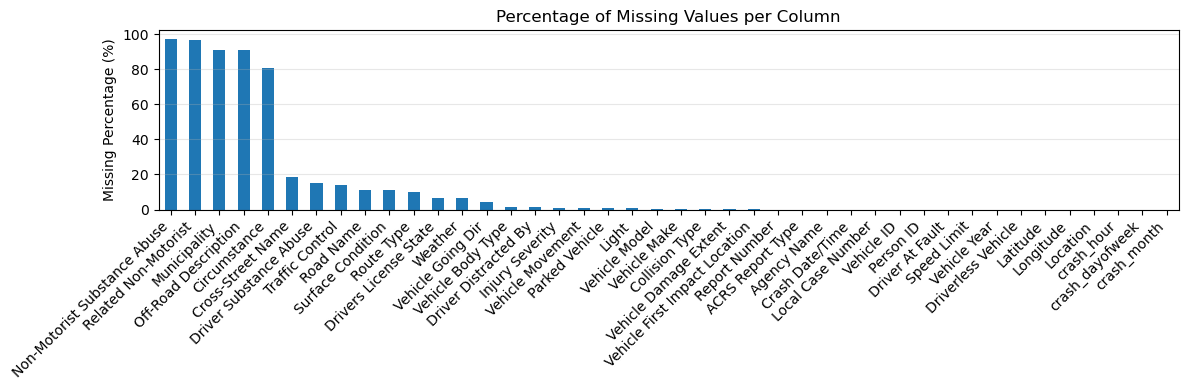

In [75]:
missing_pct = df_work.isna().mean().mul(100).sort_values(ascending=False)

plt.figure(figsize=(12,4))
missing_pct.plot(kind="bar")
plt.ylabel("Missing Percentage (%)")
plt.title("Percentage of Missing Values per Column")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [76]:
df_work.shape

(207453, 42)

In [77]:
df_work["Driver At Fault"].value_counts(dropna=False)

Driver At Fault
Yes        104294
No          98477
Unknown      4682
Name: count, dtype: int64

In [78]:
(df_work.isna().mean()*100).sort_values(ascending=False).head(5)

Non-Motorist Substance Abuse    97.284204
Related Non-Motorist            96.731790
Municipality                    90.780562
Off-Road Description            90.724164
Circumstance                    80.639470
dtype: float64

In [79]:
df_work[["Speed Limit","Vehicle Year"]].describe()

,Speed Limit,Vehicle Year
count,207453.000000,207453.000000
mean,32.170588,1965.063094
std,11.330529,342.393898
min,0.000000,0.000000
25%,25.000000,2006.000000
50%,35.000000,2012.000000
75%,40.000000,2016.000000
max,75.000000,9999.000000


In [80]:
all_unique_cols = [
    col for col in df_work.columns
    if df_work[col].nunique(dropna=False) == len(df_work)
]

all_unique_cols

['Person ID', 'Vehicle ID']

In [81]:
threshold = 0.95  

high_cardinality_cols = [
    col for col in df_work.columns
    if df_work[col].nunique(dropna=False) / len(df_work) >= threshold
]

high_cardinality_cols

['Person ID', 'Vehicle ID']

Speed Limit histogram

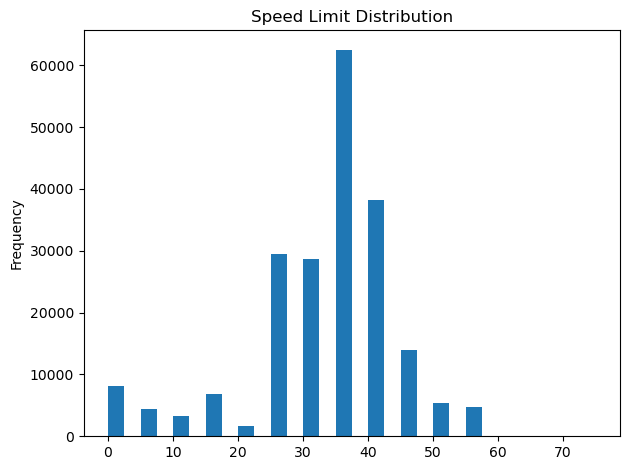

In [82]:
plt.figure()
df_work['Speed Limit'].plot(kind='hist', bins=30)
plt.title('Speed Limit Distribution')
plt.tight_layout()

Vehicle Year histogram

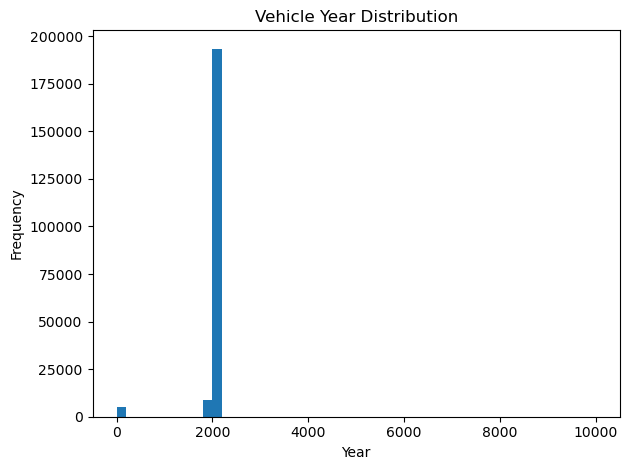

In [83]:
plt.figure()
df_work['Vehicle Year'].plot(kind='hist', bins = 50)
plt.title('Vehicle Year Distribution')
plt.xlabel('Year')
plt.tight_layout()


Weather

In [84]:
df_work['Weather'].unique()

array(['clear', 'rain', 'unknown', 'fog', 'cloudy', 'wind', 'snow', nan,
       'other', 'mixed_precipitation'], dtype=object)

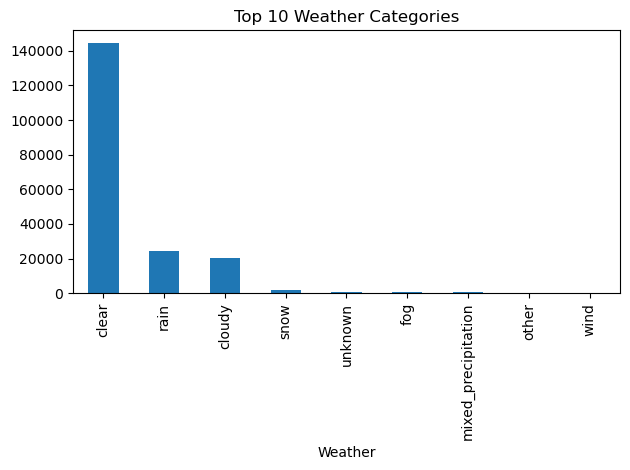

In [85]:
plt.figure()
df_work['Weather'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Weather Categories')
plt.xlabel('Weather')
plt.tight_layout()

Light

In [86]:
df_work['Light'].unique()

array(['daylight', 'dusk', 'dark_lighted', 'dark_unknown',
       'dark_not_lighted', 'dawn', 'unknown', 'other', nan], dtype=object)

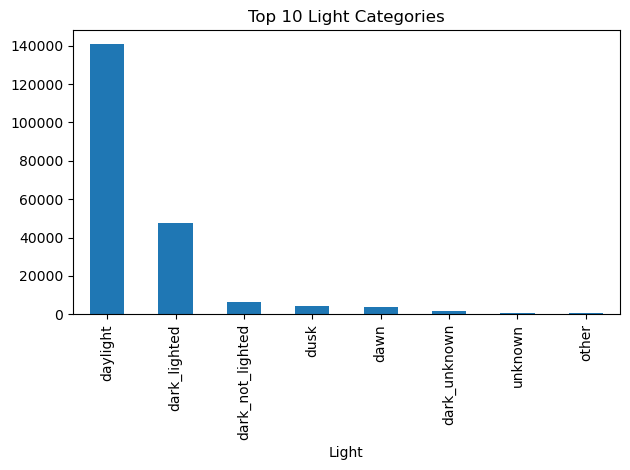

In [87]:
plt.figure()
df_work['Light'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Light Categories')
plt.xlabel('Light')
plt.tight_layout()

Collision Type

In [88]:
df_work['Collision Type'].unique()

array(['sideswipe_opposite_dir', 'sideswipe_same_dir', 'rear_end',
       'angle', 'single_vehicle', 'other', 'unknown', 'head_on', nan],
      dtype=object)

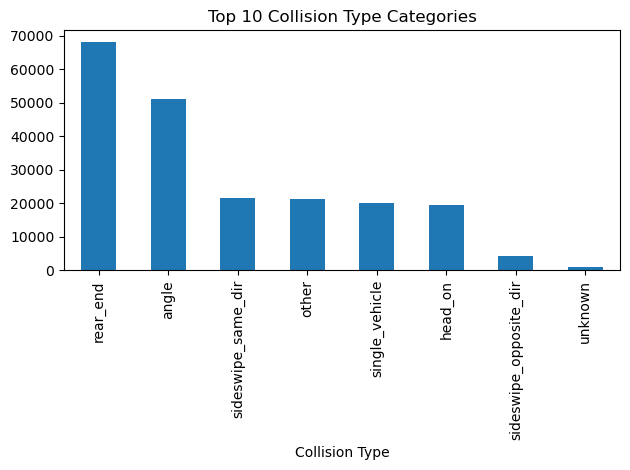

In [89]:
plt.figure()
df_work['Collision Type'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Collision Type Categories')
plt.tight_layout()

Step 2 – Data Splitting (Before Preprocessing)

Due to the manageable dataset size and relatively balanced target distribution, no sampling was applied and the full dataset was used.

In [90]:
df_work['Driver At Fault'].unique()

array(['No', 'Yes', 'Unknown'], dtype=object)

In [91]:
df_work = df_work[df_work["Driver At Fault"].isin(["Yes", "No"])].copy()
df_work['Driver At Fault'].value_counts()

Driver At Fault
Yes    104294
No      98477
Name: count, dtype: int64

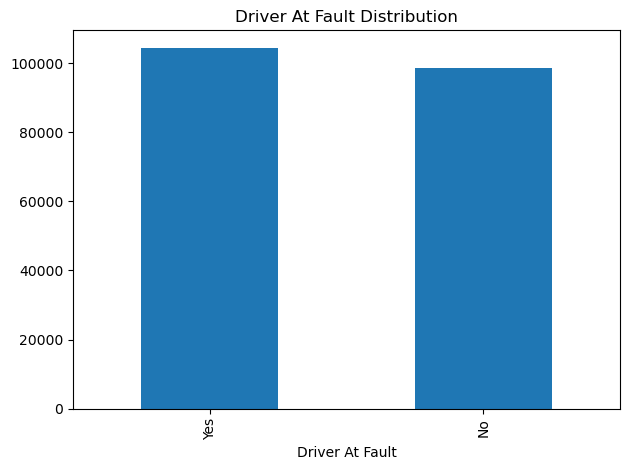

In [92]:
plt.figure()
df_work['Driver At Fault'].value_counts().plot(kind='bar')
plt.title('Driver At Fault Distribution')
plt.tight_layout()
plt.show()

In [93]:
df_work.shape

(202771, 42)

In [94]:
df_work.head()

,Report Number,Local Case Number,Agency Name,ACRS Report Type,Crash Date/Time,Route Type,Road Name,Cross-Street Name,Off-Road Description,Municipality,Related Non-Motorist,Collision Type,Weather,Surface Condition,Light,Traffic Control,Driver Substance Abuse,Non-Motorist Substance Abuse,Person ID,Driver At Fault,Injury Severity,Circumstance,Driver Distracted By,Drivers License State,Vehicle ID,Vehicle Damage Extent,Vehicle First Impact Location,Vehicle Body Type,Vehicle Movement,Vehicle Going Dir,Speed Limit,Driverless Vehicle,Parked Vehicle,Vehicle Year,Vehicle Make,Vehicle Model,Latitude,Longitude,Location,crash_hour,crash_dayofweek,crash_month
0,MCP3296002G,240018653,MONTGOMERY,Property Damage Crash,2024-04-21 18:53:00,county,NaN,NaN,NaN,NaN,NaN,sideswipe_opposite_dir,clear,dry,daylight,none,unknown,NaN,8F256727-5915-4435-9CE7-5F2D943B8DCA,No,NaN,NaN,NaN,NaN,FDDB5331-EC22-41B2-9143-124692C70CF6,disabling,Eleven O Clock,Passenger Car,Turning Left,North,25,No,No,2013,HYUNDAI,SONATA,39.105339,-76.989845,"(39.10533874, -76.98984545)",18,6,4
1,MCP276700BF,240012321,MONTGOMERY,Property Damage Crash,2024-03-14 17:23:00,state route,COLUMBIA PIKE (SB/L),NaN,NaN,NaN,NaN,sideswipe_same_dir,clear,dry,daylight,none,unknown,NaN,BB361322-2BD1-47AE-B6B4-9359BAE743A5,No,no apparent injury,NaN,NaN,NaN,7EDA4B0A-1880-4BC7-AB71-DBE62C3A9801,vehicle not at scene,Vehicle Not at Scene,Passenger Car,Passing,South,45,No,No,0,NaN,NaN,39.040003,-76.997223,"(39.04000338, -76.99722287)",17,3,3
2,MCP32790038,240022955,MONTGOMERY,Property Damage Crash,2024-05-15 07:30:00,state route,VEIRS MILL RD (WB/L),NaN,NaN,NaN,NaN,rear_end,clear,NaN,daylight,none,unknown,NaN,E04C495C-1DE3-4AC9-B507-A9B2C207056C,No,NaN,NaN,NaN,NaN,BBAC2C29-9197-40D8-9B22-9156FA82B6F1,vehicle not at scene,Vehicle Not at Scene,Passenger Car,Moving Constant Speed,North,45,No,No,2006,CHEVROLET,COBALT,39.073096,-77.111254,"(39.0730963, -77.1112541)",7,2,5
3,MCP34000014,240019831,MONTGOMERY,Property Damage Crash,2024-04-28 17:30:00,county,HARDING DR,NaN,NaN,NaN,NaN,rear_end,clear,dry,daylight,none,unknown,NaN,D7E62A5D-C733-490D-AC9C-B5EA089C651E,No,NaN,NaN,NaN,NaN,3ACB0037-C9D5-48C5-B410-BE986F22CA86,functional,One O Clock,Passenger Car,Moving Constant Speed,South,25,No,No,2012,NISSAN,ALTIMA,39.021944,-77.018300,"(39.02194389, -77.01829961)",17,6,4
4,MCP3341003F,240011829,MONTGOMERY,Injury Crash,2024-03-12 07:30:00,private route,NaN,CONNECTICUT AVE,NaN,NaN,NaN,angle,clear,dry,daylight,none,unknown,NaN,41AB0CCC-A509-40FF-9BE4-26BB809D02FE,No,no apparent injury,NaN,NaN,NaN,785A7E9D-DC33-45B9-B111-7BA14EAC416B,functional,Twelve O Clock,Pickup / Light Truck,Turning Left,South,35,No,NaN,2015,CHEVROLET,SILVERADO,39.090304,-77.071180,"(39.09030389, -77.07118035)",7,1,3


In [95]:
y = df_work['Driver At Fault']
not_x = ['Driver At Fault', 'Agency Name', 'ACRS Report Type', 'Crash Date/Time', 'Road Name', 'Cross-Street Name', 'Injury Severity',
'Vehicle Damage Extent', 'Vehicle First Impact Location', 'Vehicle Make', 'Vehicle Model', 'Location']
X = df_work.drop(columns= not_x)

In [96]:
X.columns

Index(['Report Number', 'Local Case Number', 'Route Type',
       'Off-Road Description', 'Municipality', 'Related Non-Motorist',
       'Collision Type', 'Weather', 'Surface Condition', 'Light',
       'Traffic Control', 'Driver Substance Abuse',
       'Non-Motorist Substance Abuse', 'Person ID', 'Circumstance',
       'Driver Distracted By', 'Drivers License State', 'Vehicle ID',
       'Vehicle Body Type', 'Vehicle Movement', 'Vehicle Going Dir',
       'Speed Limit', 'Driverless Vehicle', 'Parked Vehicle', 'Vehicle Year',
       'Latitude', 'Longitude', 'crash_hour', 'crash_dayofweek',
       'crash_month'],
      dtype='object')

In [97]:
from sklearn.model_selection import StratifiedGroupKFold

if "Report Number" in df_work.columns:
    groups = df_work.loc[X.index, "Report Number"]
elif "Local Case Number" in df_work.columns:
    groups = df_work.loc[X.index, "Local Case Number"]
else:
    groups = None

if groups is not None:
    groups = groups.fillna("MISSING_GROUP").astype(str)

    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

    trainval_idx, test_idx = next(sgkf.split(X, y, groups=groups))

    X_temp = X.iloc[trainval_idx].copy()
    y_temp = y.iloc[trainval_idx].copy()

    X_test = X.iloc[test_idx].copy()
    y_test = y.iloc[test_idx].copy()
else:
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

In [98]:
from sklearn.model_selection import StratifiedGroupKFold

if "groups" in globals() and groups is not None:
    groups_temp = groups.iloc[trainval_idx].copy()

    sgkf2 = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=42)
    train_idx, val_idx = next(sgkf2.split(X_temp, y_temp, groups=groups_temp))

    X_train = X_temp.iloc[train_idx].copy()
    y_train = y_temp.iloc[train_idx].copy()

    X_val = X_temp.iloc[val_idx].copy()
    y_val = y_temp.iloc[val_idx].copy()
else:
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp,
        test_size=0.25,
        random_state=42,
        stratify=y_temp
    )

In [99]:
thr_missing_col = 0.80
missing_rate = X_train.isna().mean().sort_values(ascending=False)

missing_cols = missing_rate[missing_rate > thr_missing_col].head(5).index.tolist()

X_train = X_train.drop(columns=missing_cols, errors="ignore")
X_val   = X_val.drop(columns=missing_cols, errors="ignore")
X_test  = X_test.drop(columns=missing_cols, errors="ignore")


id_identity_cols = ["Report Number", "Local Case Number", "Person ID", "Vehicle ID"]
present_id_cols = [c for c in id_identity_cols if c in X_train.columns]

X_train = X_train.drop(columns=present_id_cols, errors="ignore")
X_val   = X_val.drop(columns=present_id_cols, errors="ignore")
X_test  = X_test.drop(columns=present_id_cols, errors="ignore")


thr_const = 0.97
const_cols = []
for col in X_train.columns:
    top_ratio = X_train[col].value_counts(normalize=True, dropna=False).iloc[0]
    if top_ratio > thr_const:
        const_cols.append(col)

X_train = X_train.drop(columns=const_cols, errors="ignore")
X_val   = X_val.drop(columns=const_cols, errors="ignore")
X_test  = X_test.drop(columns=const_cols, errors="ignore")


thr_row = 0.30

row_missing = X_train.isna().mean(axis=1)
keep_train = row_missing <= thr_row
X_train = X_train.loc[keep_train].copy()
y_train = y_train.loc[keep_train].copy()

row_missing_val = X_val.isna().mean(axis=1)
keep_val = row_missing_val <= thr_row
X_val = X_val.loc[keep_val].copy()
y_val = y_val.loc[keep_val].copy()

row_missing_test = X_test.isna().mean(axis=1)
keep_test = row_missing_test <= thr_row
X_test = X_test.loc[keep_test].copy()
y_test = y_test.loc[keep_test].copy()


print("Dropped cols (>80% missing, up to 5):", len(missing_cols), missing_cols)
print("Dropped ID cols:", len(present_id_cols), present_id_cols)
print("Dropped cols (near-constant):", len(const_cols))
print("Rows removed (train/val/test):",
      (~keep_train).sum(), (~keep_val).sum(), (~keep_test).sum())

print("Shapes (train/val/test):", X_train.shape, X_val.shape, X_test.shape)
assert list(X_train.columns) == list(X_val.columns) == list(X_test.columns)

print("Train:", y_train.value_counts(normalize=True))
print("Validation:", y_val.value_counts(normalize=True))
print("Test:", y_test.value_counts(normalize=True))


group_col = None
if "Report Number" in df_work.columns:
    group_col = "Report Number"
elif "Local Case Number" in df_work.columns:
    group_col = "Local Case Number"


if group_col is not None and ("trainval_idx" in globals()):
    g_train = set(df_work.loc[X_train.index, group_col].fillna("MISSING_GROUP").astype(str))
    g_val   = set(df_work.loc[X_val.index, group_col].fillna("MISSING_GROUP").astype(str))
    g_test  = set(df_work.loc[X_test.index, group_col].fillna("MISSING_GROUP").astype(str))

    print("Group overlap (train ∩ val):", len(g_train & g_val))
    print("Group overlap (train ∩ test):", len(g_train & g_test))
    print("Group overlap (val ∩ test):", len(g_val & g_test))

Dropped cols (>80% missing, up to 5): 5 ['Non-Motorist Substance Abuse', 'Related Non-Motorist', 'Municipality', 'Off-Road Description', 'Circumstance']
Dropped ID cols: 4 ['Report Number', 'Local Case Number', 'Person ID', 'Vehicle ID']
Dropped cols (near-constant): 2
Rows removed (train/val/test): 292 88 88
Shapes (train/val/test): (120896, 19) (40615, 19) (40792, 19)
Train: Driver At Fault
Yes    0.514914
No     0.485086
Name: proportion, dtype: float64
Validation: Driver At Fault
Yes    0.515844
No     0.484156
Name: proportion, dtype: float64
Test: Driver At Fault
Yes    0.512527
No     0.487473
Name: proportion, dtype: float64
Group overlap (train ∩ val): 0
Group overlap (train ∩ test): 0
Group overlap (val ∩ test): 0


The dataset was split into training (60%), validation (20%), and test (20%) sets using stratified sampling based on the target variable (Driver At Fault). This ensured that the class distribution remained consistent across all subsets, preventing class imbalance distortion during model training and evaluation.

In [100]:
y_train_bin = y_train.map({"Yes": 1, "No": 0})
y_val_bin   = y_val.map({"Yes": 1, "No": 0})
y_test_bin  = y_test.map({"Yes": 1, "No": 0})

In [101]:
numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
corr_num = X_train[numeric_cols].corrwith(y_train_bin).abs().sort_values(ascending=False)
corr_num

Speed Limit     0.098319
Vehicle Year    0.059372
Latitude        0.026021
Longitude       0.020090
dtype: float64

To compare imputation strategies, simple and advanced methods were applied independently on identical training data containing missing values.

Step 3 – Missing Values Handling

In [102]:
X_train_simple  = X_train.copy()
X_train_complex = X_train.copy()
X_val_simple = X_val.copy()
X_val_complex = X_val.copy()
X_test_simple   = X_test.copy()
X_test_complex  = X_test.copy()

In [103]:
num_cols = X_train_simple.select_dtypes(include="number").columns
cat_cols = X_train_simple.select_dtypes(exclude="number").columns

medians = X_train_simple[num_cols].median()

X_train_simple[num_cols] = X_train_simple[num_cols].fillna(medians)
X_val_simple[num_cols]   = X_val_simple[num_cols].fillna(medians)
X_test_simple[num_cols]  = X_test_simple[num_cols].fillna(medians)

modes = X_train_simple[cat_cols].mode(dropna=True).iloc[0]

X_train_simple[cat_cols] = X_train_simple[cat_cols].fillna(modes)
X_val_simple[cat_cols]   = X_val_simple[cat_cols].fillna(modes)
X_test_simple[cat_cols]  = X_test_simple[cat_cols].fillna(modes)

In [104]:
from sklearn.impute import KNNImputer

num_cols = X_train_complex.select_dtypes(include="number").columns
cat_cols = X_train_complex.select_dtypes(exclude="number").columns

knn = KNNImputer(n_neighbors=5)

X_train_complex[num_cols] = knn.fit_transform(X_train_complex[num_cols])
X_val_complex[num_cols]   = knn.transform(X_val_complex[num_cols])
X_test_complex[num_cols]  = knn.transform(X_test_complex[num_cols])

modes = X_train_complex[cat_cols].mode(dropna=True).iloc[0]

X_train_complex[cat_cols] = X_train_complex[cat_cols].fillna(modes)
X_val_complex[cat_cols]   = X_val_complex[cat_cols].fillna(modes)
X_test_complex[cat_cols]  = X_test_complex[cat_cols].fillna(modes)

In [105]:
print("Simple  :",
      X_train_simple.isna().sum().sum(),
      X_val_simple.isna().sum().sum(),
      X_test_simple.isna().sum().sum())

print("Complex :",
      X_train_complex.isna().sum().sum(),
      X_val_complex.isna().sum().sum(),
      X_test_complex.isna().sum().sum())

Simple  : 0 0 0
Complex : 0 0 0


Top missingness (train):


,missing_rate_train
Driver Substance Abuse,0.149029
Traffic Control,0.136357
Surface Condition,0.110475
Route Type,0.094676
Drivers License State,0.064469
Weather,0.062483
Vehicle Going Dir,0.042996
Vehicle Body Type,0.013764
Driver Distracted By,0.011440
Light,0.007006


<Figure size 640x480 with 0 Axes>

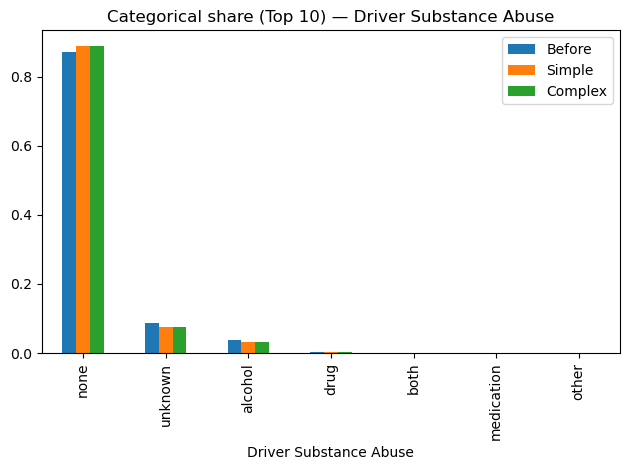

<Figure size 640x480 with 0 Axes>

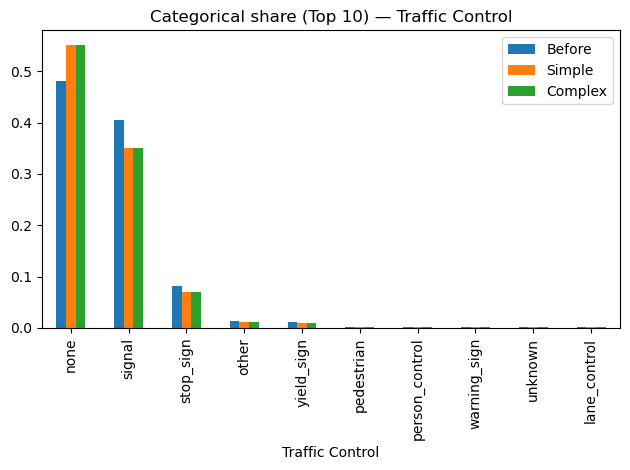

In [106]:
from IPython.display import display

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

na_rate = X_train.isna().mean().sort_values(ascending=False)
missing_cols = na_rate[na_rate > 0].index.tolist()

if len(missing_cols) == 0:
    print("No missing values detected in X_train (before imputation). If your project requires it, create ~5% artificial missingness in a few columns.")
else:
    num_rep = [c for c in missing_cols if pd.api.types.is_numeric_dtype(X_train[c])][:3]
    cat_rep = [c for c in missing_cols if not pd.api.types.is_numeric_dtype(X_train[c])][:2]

    print("Top missingness (train):")
    display(na_rate.head(10).to_frame("missing_rate_train"))

    def plot_numeric(col, bins=30):
        plt.figure()
        pre = X_train[col].dropna()
        s   = X_train_simple[col]
        c   = X_train_complex[col]
        plt.hist(pre, bins=bins, density=True, alpha=0.45, label="Before (dropna)")
        plt.hist(s,   bins=bins, density=True, alpha=0.45, label="Simple (median)")
        plt.hist(c,   bins=bins, density=True, alpha=0.45, label="Complex (KNN)")
        plt.title(f"Numeric distribution — {col}")
        plt.legend()
        plt.tight_layout()
        plt.show()

    def plot_categorical(col, topn=10):
        plt.figure()
        pre = X_train[col].astype("object")
        s   = X_train_simple[col].astype("object")
        c   = X_train_complex[col].astype("object")

        top_cats = pd.concat([pre, s, c]).value_counts().head(topn).index

        comp = pd.DataFrame({
            "Before": pre.value_counts(normalize=True).reindex(top_cats).fillna(0),
            "Simple": s.value_counts(normalize=True).reindex(top_cats).fillna(0),
            "Complex": c.value_counts(normalize=True).reindex(top_cats).fillna(0),
        })
        comp.plot(kind="bar")
        plt.title(f"Categorical share (Top {topn}) — {col}")
        plt.tight_layout()
        plt.show()

    for col in num_rep:
        plot_numeric(col)

    for col in cat_rep:
        plot_categorical(col)

Missing values were handled using two independent strategies.
A simple baseline approach (median for numerical and mode for categorical features) and an advanced approach using KNN imputation for numerical features were applied separately on the same training data to allow fair comparison.

Step 4 – Outlier Detection & Treatment

In [107]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

Xs_tr  = X_train_simple.copy()
Xs_val = X_val_simple.copy()
Xs_te  = X_test_simple.copy()

Xc_tr  = X_train_complex.copy()
Xc_val = X_val_complex.copy()
Xc_te  = X_test_complex.copy()

INVALID_MAP = {"Vehicle Year": [0, 9999]}

ISO_FLAG_PERCENTILE = 1

In [108]:
def fit_invalid_imputer(X_train, invalid_map):
    X = X_train.copy()
    medians = {}

    for col, bad_values in invalid_map.items():
        if col in X.columns:
            X.loc[X[col].isin(bad_values), col] = np.nan
            medians[col] = X[col].median()  
            X[col] = X[col].fillna(medians[col])

    return X, medians

def apply_invalid_imputer(X, invalid_map, medians):
    X2 = X.copy()
    for col, bad_values in invalid_map.items():
        if col in X2.columns:
            X2.loc[X2[col].isin(bad_values), col] = np.nan
            if col in medians:
                X2[col] = X2[col].fillna(medians[col])
    return X2

In [109]:
# Simple
Xs_tr, med_simple = fit_invalid_imputer(Xs_tr, INVALID_MAP)
Xs_val = apply_invalid_imputer(Xs_val, INVALID_MAP, med_simple)
Xs_te  = apply_invalid_imputer(Xs_te,  INVALID_MAP, med_simple)

# Complex
Xc_tr, med_complex = fit_invalid_imputer(Xc_tr, INVALID_MAP)
Xc_val = apply_invalid_imputer(Xc_val, INVALID_MAP, med_complex)
Xc_te  = apply_invalid_imputer(Xc_te,  INVALID_MAP, med_complex)

In [110]:
num_cols_s = Xs_tr.select_dtypes(include="number").columns

iqr_bounds = {}
iqr_outlier_flags_tr = {}

for c in num_cols_s:
    q1 = Xs_tr[c].quantile(0.25)
    q3 = Xs_tr[c].quantile(0.75)
    iqr = q3 - q1
    if iqr == 0 or np.isnan(iqr):
        continue

    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr

    iqr_bounds[c] = (low, high)
    iqr_outlier_flags_tr[c] = (Xs_tr[c] < low) | (Xs_tr[c] > high)

iqr_outlier_df_tr = pd.DataFrame(iqr_outlier_flags_tr, index=Xs_tr.index)

In [111]:
iqr_outlier_percent = iqr_outlier_df_tr.mean().sort_values(ascending=False) * 100
iqr_outlier_percent

Speed Limit        3.834701
Vehicle Year       0.792417
Longitude          0.258900
Latitude           0.186110
crash_hour         0.000000
crash_dayofweek    0.000000
crash_month        0.000000
dtype: float64

In [112]:
iqr_flag_tr = iqr_outlier_df_tr.any(axis=1)

def make_iqr_row_flag(df, bounds):
    flags = []
    for c, (low, high) in bounds.items():
        if c in df.columns:
            flags.append((df[c] < low) | (df[c] > high))
    if len(flags) == 0:
        return pd.Series(False, index=df.index)
    return pd.concat(flags, axis=1).any(axis=1)

iqr_flag_val = make_iqr_row_flag(Xs_val, iqr_bounds)
iqr_flag_te  = make_iqr_row_flag(Xs_te,  iqr_bounds)

In [113]:
def iqr_cap(df, bounds):
    df2 = df.copy()
    for c, (low, high) in bounds.items():
        if c in df2.columns:
            df2[c] = df2[c].clip(lower=low, upper=high)
    return df2

Xs_tr_capped  = iqr_cap(Xs_tr,  iqr_bounds)
Xs_val_capped = iqr_cap(Xs_val, iqr_bounds)
Xs_te_capped  = iqr_cap(Xs_te,  iqr_bounds)

Xs_tr_capped["iqr_outlier_flag"]  = iqr_flag_tr.astype(int)
Xs_val_capped["iqr_outlier_flag"] = iqr_flag_val.astype(int)
Xs_te_capped["iqr_outlier_flag"]  = iqr_flag_te.astype(int)

In [114]:
num_cols_c = Xc_tr.select_dtypes(include="number").columns

scaler_iso = StandardScaler()
Xtr_scaled = scaler_iso.fit_transform(Xc_tr[num_cols_c])
Xval_scaled = scaler_iso.transform(Xc_val[num_cols_c])
Xte_scaled  = scaler_iso.transform(Xc_te[num_cols_c])

iso = IsolationForest(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
iso.fit(Xtr_scaled)

score_tr  = iso.decision_function(Xtr_scaled)
score_val = iso.decision_function(Xval_scaled)
score_te  = iso.decision_function(Xte_scaled)

threshold_iso = np.percentile(score_tr, ISO_FLAG_PERCENTILE)

iso_flag_tr  = (score_tr  < threshold_iso).astype(int)
iso_flag_val = (score_val < threshold_iso).astype(int)
iso_flag_te  = (score_te  < threshold_iso).astype(int)

In [115]:
Xc_tr_out  = Xc_tr.copy()
Xc_val_out = Xc_val.copy()
Xc_te_out  = Xc_te.copy()

Xc_tr_out["iso_score"]  = score_tr
Xc_val_out["iso_score"] = score_val
Xc_te_out["iso_score"]  = score_te

Xc_tr_out["iso_outlier_flag"]  = iso_flag_tr
Xc_val_out["iso_outlier_flag"] = iso_flag_val
Xc_te_out["iso_outlier_flag"]  = iso_flag_te

Xs_tr_capped["iso_outlier_flag"]  = pd.Series(iso_flag_tr, index=Xc_tr.index)
Xs_val_capped["iso_outlier_flag"] = pd.Series(iso_flag_val, index=Xc_val.index)
Xs_te_capped["iso_outlier_flag"]  = pd.Series(iso_flag_te, index=Xc_te.index)

Xs_tr_capped["iso_score"]  = pd.Series(score_tr,  index=Xc_tr.index)
Xs_val_capped["iso_score"] = pd.Series(score_val, index=Xc_val.index)
Xs_te_capped["iso_score"]  = pd.Series(score_te,  index=Xc_te.index)

In [116]:
print("IQR outlier rows % (Train/Val/Test):",
      Xs_tr_capped["iqr_outlier_flag"].mean()*100,
      Xs_val_capped["iqr_outlier_flag"].mean()*100,
      Xs_te_capped["iqr_outlier_flag"].mean()*100)

print("IsolationForest outlier rows % (iso_outlier_flag) (Train/Val/Test):",
      Xc_tr_out["iso_outlier_flag"].mean()*100,
      Xc_val_out["iso_outlier_flag"].mean()*100,
      Xc_te_out["iso_outlier_flag"].mean()*100)

IQR outlier rows % (Train/Val/Test): 4.993548173636845 4.904591899544504 4.910276524808786
IsolationForest outlier rows % (iso_outlier_flag) (Train/Val/Test): 1.0000330862890419 0.9996306783208173 1.0443224161600313


Step 5 – Feature Scaling / Normalization

In [117]:
from sklearn.preprocessing import StandardScaler

num_cols_s = Xs_tr_capped.select_dtypes(include="number").columns.tolist()

flag_cols_s = [c for c in num_cols_s if c.endswith("flag")]

scale_cols_s = [c for c in num_cols_s if c not in flag_cols_s]

num_cols_s, flag_cols_s, scale_cols_s[:10], len(scale_cols_s)

(['Speed Limit',
  'Vehicle Year',
  'Latitude',
  'Longitude',
  'crash_hour',
  'crash_dayofweek',
  'crash_month',
  'iqr_outlier_flag',
  'iso_outlier_flag',
  'iso_score'],
 ['iqr_outlier_flag', 'iso_outlier_flag'],
 ['Speed Limit',
  'Vehicle Year',
  'Latitude',
  'Longitude',
  'crash_hour',
  'crash_dayofweek',
  'crash_month',
  'iso_score'],
 8)

In [118]:
from sklearn.preprocessing import StandardScaler

scaler_simple = StandardScaler()

Xs_tr_scaled  = Xs_tr_capped.copy()
Xs_val_scaled = Xs_val_capped.copy()
Xs_te_scaled  = Xs_te_capped.copy()

Xs_tr_scaled[scale_cols_s]  = scaler_simple.fit_transform(Xs_tr_capped[scale_cols_s])
Xs_val_scaled[scale_cols_s] = scaler_simple.transform(Xs_val_capped[scale_cols_s])
Xs_te_scaled[scale_cols_s]  = scaler_simple.transform(Xs_te_capped[scale_cols_s])

In [119]:
X_train_dt = Xs_tr_capped.copy()
X_val_dt   = Xs_val_capped.copy()
X_test_dt  = Xs_te_capped.copy()

X_train_scaled = Xs_tr_scaled.copy()
X_val_scaled   = Xs_val_scaled.copy()
X_test_scaled  = Xs_te_scaled.copy()

In [120]:
from IPython.display import display

import numpy as np
import pandas as pd

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score

def make_design_matrix(train_df, val_df):
    cat_cols = train_df.select_dtypes(include=["object", "string", "category"]).columns.tolist()
    num_cols = [c for c in train_df.columns if c not in cat_cols]

    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

    if len(cat_cols) > 0:
        Xtr_cat  = ohe.fit_transform(train_df[cat_cols])
        Xval_cat = ohe.transform(val_df[cat_cols])
    else:
        Xtr_cat  = np.empty((len(train_df), 0))
        Xval_cat = np.empty((len(val_df), 0))

    if len(num_cols) > 0:
        Xtr_num  = train_df[num_cols].to_numpy(dtype=float)
        Xval_num = val_df[num_cols].to_numpy(dtype=float)
    else:
        Xtr_num  = np.empty((len(train_df), 0))
        Xval_num = np.empty((len(val_df), 0))

    Xtr  = np.hstack([Xtr_num, Xtr_cat])
    Xval = np.hstack([Xval_num, Xval_cat])
    return Xtr, Xval

def eval_dt(train_df, val_df, y_tr, y_v):
    Xtr, Xval = make_design_matrix(train_df, val_df)
    clf = DecisionTreeClassifier(max_depth=10, random_state=42)
    clf.fit(Xtr, y_tr)
    pred = clf.predict(Xval)
    return {
        "acc": accuracy_score(y_v, pred),
        "f1_macro": f1_score(y_v, pred, average="macro")
    }

def eval_svm(train_df, val_df, y_tr, y_v):
    Xtr, Xval = make_design_matrix(train_df, val_df)
    clf = LinearSVC(C=1.0, max_iter=3000, random_state=42)
    clf.fit(Xtr, y_tr)
    pred = clf.predict(Xval)
    return {
        "acc": accuracy_score(y_v, pred),
        "f1_macro": f1_score(y_v, pred, average="macro")
    }

def eval_knn(train_df, val_df, y_tr, y_v, k=11):
    Xtr, Xval = make_design_matrix(train_df, val_df)
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(Xtr, y_tr)
    pred = clf.predict(Xval)
    return {
        "acc": accuracy_score(y_v, pred),
        "f1_macro": f1_score(y_v, pred, average="macro")
    }

def compute_iqr_bounds(train_df):
    bounds = {}
    for c in train_df.select_dtypes(include="number").columns:
        q1 = train_df[c].quantile(0.25)
        q3 = train_df[c].quantile(0.75)
        iqr = q3 - q1
        if pd.isna(iqr) or iqr == 0:
            continue
        bounds[c] = (q1 - 1.5 * iqr, q3 + 1.5 * iqr)
    return bounds

def iqr_cap_df(df, bounds):
    out = df.copy()
    for c, (low, high) in bounds.items():
        if c in out.columns:
            out[c] = out[c].clip(lower=low, upper=high)
    return out

def iqr_row_flag(df, bounds):
    flags = []
    for c, (low, high) in bounds.items():
        if c in df.columns:
            flags.append((df[c] < low) | (df[c] > high))
    if len(flags) == 0:
        return pd.Series(False, index=df.index)
    return pd.concat(flags, axis=1).any(axis=1)

def scale_like(train_df, val_df):
    num_cols = train_df.select_dtypes(include="number").columns.tolist()
    flag_cols = [c for c in num_cols if c.endswith("flag")]
    scale_cols = [c for c in num_cols if c not in flag_cols]

    scaler = StandardScaler()
    tr_s = train_df.copy()
    va_s = val_df.copy()

    if len(scale_cols) > 0:
        tr_s[scale_cols] = scaler.fit_transform(train_df[scale_cols])
        va_s[scale_cols] = scaler.transform(val_df[scale_cols])

    return tr_s, va_s


A_dt_tr, A_dt_val = X_train_dt.copy(), X_val_dt.copy()
A_sc_tr, A_sc_val = X_train_scaled.copy(), X_val_scaled.copy()

A_sc_tr_noiso  = A_sc_tr.drop(columns=["iso_score", "iso_outlier_flag"], errors="ignore")
A_sc_val_noiso = A_sc_val.drop(columns=["iso_score", "iso_outlier_flag"], errors="ignore")


bounds_c = compute_iqr_bounds(Xc_tr)
B_tr_flag = iqr_row_flag(Xc_tr, bounds_c).astype(int)
B_val_flag = iqr_row_flag(Xc_val, bounds_c).astype(int)

B_dt_tr  = iqr_cap_df(Xc_tr, bounds_c)
B_dt_val = iqr_cap_df(Xc_val, bounds_c)

B_dt_tr["iqr_outlier_flag"]  = B_tr_flag
B_dt_val["iqr_outlier_flag"] = B_val_flag

B_sc_tr, B_sc_val = scale_like(B_dt_tr, B_dt_val)


rows = []

a_dt  = eval_dt(A_dt_tr, A_dt_val, y_train, y_val)
a_svm = eval_svm(A_sc_tr, A_sc_val, y_train, y_val)
a_knn = eval_knn(A_sc_tr, A_sc_val, y_train, y_val, k=11)
rows.append({"pipeline": "A) Simple imputation", "DT_acc": a_dt["acc"], "DT_f1": a_dt["f1_macro"],
             "SVM_acc": a_svm["acc"], "SVM_f1": a_svm["f1_macro"], "KNN_acc": a_knn["acc"], "KNN_f1": a_knn["f1_macro"]})

b_dt  = eval_dt(B_dt_tr, B_dt_val, y_train, y_val)
b_svm = eval_svm(B_sc_tr, B_sc_val, y_train, y_val)
b_knn = eval_knn(B_sc_tr, B_sc_val, y_train, y_val, k=11)
rows.append({"pipeline": "B) KNN imputation", "DT_acc": b_dt["acc"], "DT_f1": b_dt["f1_macro"],
             "SVM_acc": b_svm["acc"], "SVM_f1": b_svm["f1_macro"], "KNN_acc": b_knn["acc"], "KNN_f1": b_knn["f1_macro"]})

cmp = pd.DataFrame(rows).set_index("pipeline")
display(cmp)


if ("iso_score" in A_sc_tr.columns) or ("iso_outlier_flag" in A_sc_tr.columns):
    svm_with  = eval_svm(A_sc_tr,      A_sc_val,      y_train, y_val)
    svm_noiso = eval_svm(A_sc_tr_noiso, A_sc_val_noiso, y_train, y_val)

    iso_cmp = pd.DataFrame([
        {"variant": "SVM with iso_score/flag", "acc": svm_with["acc"], "f1_macro": svm_with["f1_macro"]},
        {"variant": "SVM without iso_score/flag", "acc": svm_noiso["acc"], "f1_macro": svm_noiso["f1_macro"]},
    ]).set_index("variant")
    display(iso_cmp)
else:
    print("iso_score / iso_outlier_flag not found in X_train_scaled — if you want to 'use' IsolationForest in the pipeline, add iso_score to Xs_*_capped in Cell 138.")

,DT_acc,DT_f1,SVM_acc,SVM_f1,KNN_acc,KNN_f1
pipeline,,,,,,
A) Simple imputation,0.833928,0.833745,0.816866,0.816814,0.787271,0.786497
B) KNN imputation,0.833559,0.833371,0.817284,0.817234,0.791038,0.790306


,acc,f1_macro
variant,,
SVM with iso_score/flag,0.816866,0.816814
SVM without iso_score/flag,0.817284,0.817234


In [121]:
train_mean = Xs_tr_scaled[scale_cols_s].mean()
train_std  = Xs_tr_scaled[scale_cols_s].std()

print("Mean abs avg:", train_mean.abs().mean())
print("Std abs diff from 1 avg:", (train_std - 1).abs().mean())

Mean abs avg: 1.2720531645261493e-14
Std abs diff from 1 avg: 4.135811782407517e-06


Step 6 – Supervised Learning: Classification

6.1 Baseline Models

6.1.1 Decision Tree

In [122]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np

cat_cols_dt = X_train_dt.select_dtypes(include=["object", "string", "category"]).columns.tolist()
num_cols_dt = [c for c in X_train_dt.columns if c not in cat_cols_dt]

ohe_dt = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

Xtr_cat_dt  = ohe_dt.fit_transform(X_train_dt[cat_cols_dt])
Xval_cat_dt = ohe_dt.transform(X_val_dt[cat_cols_dt])
Xte_cat_dt  = ohe_dt.transform(X_test_dt[cat_cols_dt])

Xtr_num_dt  = X_train_dt[num_cols_dt].to_numpy(dtype=float)
Xval_num_dt = X_val_dt[num_cols_dt].to_numpy(dtype=float)
Xte_num_dt  = X_test_dt[num_cols_dt].to_numpy(dtype=float)

Xtr_final_dt  = np.hstack([Xtr_num_dt, Xtr_cat_dt])
Xval_final_dt = np.hstack([Xval_num_dt, Xval_cat_dt])
Xte_final_dt  = np.hstack([Xte_num_dt, Xte_cat_dt])

In [123]:
Xs_tr_scaled.dtypes

Route Type                string[python]
Collision Type                    object
Weather                           object
Surface Condition                 object
Light                             object
Traffic Control                   object
Driver Substance Abuse            object
Driver Distracted By              object
Drivers License State             object
Vehicle Body Type                 object
Vehicle Movement                  object
Vehicle Going Dir                 object
Speed Limit                      float64
Vehicle Year                     float64
Latitude                         float64
Longitude                        float64
crash_hour                       float64
crash_dayofweek                  float64
crash_month                      float64
iqr_outlier_flag                   int64
iso_outlier_flag                   int64
iso_score                        float64
dtype: object

In [124]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

depths = [3, 5, 7, 10, None]
dt_results = {}

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(Xtr_final_dt, y_train)
    y_pred = dt.predict(Xval_final_dt)
    dt_results[d] = accuracy_score(y_val, y_pred)

dt_results

{3: 0.7948294964914441,
 5: 0.796946940785424,
 7: 0.8215437646189832,
 10: 0.8339283515942386,
 None: 0.7717345808198941}

In [125]:
from sklearn.metrics import confusion_matrix, classification_report

dt_final = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_final.fit(Xtr_final_dt, y_train)

y_val_pred = dt_final.predict(Xval_final_dt)

print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print(confusion_matrix(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))

Validation Accuracy: 0.8339283515942386
[[16260  3404]
 [ 3341 17610]]
              precision    recall  f1-score   support

          No       0.83      0.83      0.83     19664
         Yes       0.84      0.84      0.84     20951

    accuracy                           0.83     40615
   macro avg       0.83      0.83      0.83     40615
weighted avg       0.83      0.83      0.83     40615



In [126]:
y_test_pred = dt_final.predict(Xte_final_dt)

print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print(confusion_matrix(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))

Test Accuracy: 0.8324916650323593
[[16414  3471]
 [ 3362 17545]]
              precision    recall  f1-score   support

          No       0.83      0.83      0.83     19885
         Yes       0.83      0.84      0.84     20907

    accuracy                           0.83     40792
   macro avg       0.83      0.83      0.83     40792
weighted avg       0.83      0.83      0.83     40792



6.1.2 K-Nearest Neighbors

In [127]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np

cat_cols_knn = X_train_scaled.select_dtypes(include=["object", "string", "category"]).columns.tolist()
num_cols_knn = [c for c in X_train_scaled.columns if c not in cat_cols_knn]

ohe_knn = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

Xtr_cat_knn  = ohe_knn.fit_transform(X_train_scaled[cat_cols_knn])
Xval_cat_knn = ohe_knn.transform(X_val_scaled[cat_cols_knn])
Xte_cat_knn  = ohe_knn.transform(X_test_scaled[cat_cols_knn])

Xtr_num_knn  = X_train_scaled[num_cols_knn].to_numpy(dtype=float)
Xval_num_knn = X_val_scaled[num_cols_knn].to_numpy(dtype=float)
Xte_num_knn  = X_test_scaled[num_cols_knn].to_numpy(dtype=float)

Xtr_final_knn  = np.hstack([Xtr_num_knn, Xtr_cat_knn])
Xval_final_knn = np.hstack([Xval_num_knn, Xval_cat_knn])
Xte_final_knn  = np.hstack([Xte_num_knn, Xte_cat_knn])

In [128]:
Xtr_final  = Xtr_final_knn
Xval_final = Xval_final_knn
Xte_final  = Xte_final_knn

Feature Selection

In [129]:
import numpy as np
import pandas as pd
from IPython.display import display

from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression

if "y_train_bin" in globals() and "y_val_bin" in globals():
    y_fs_tr = y_train_bin
    y_fs_val = y_val_bin
else:
    y_fs_tr = y_train.map({"Yes": 1, "No": 0})
    y_fs_val = y_val.map({"Yes": 1, "No": 0})

try:
    feature_names = list(num_cols_knn) + list(ohe_knn.get_feature_names_out(cat_cols_knn))
except Exception:
    feature_names = [f"f{i}" for i in range(Xtr_final.shape[1])]

if len(feature_names) != Xtr_final.shape[1]:
    feature_names = [f"f{i}" for i in range(Xtr_final.shape[1])]

print("Total features:", Xtr_final.shape[1])

Total features: 131


In [130]:
k = min(40, Xtr_final.shape[1])  
mi_sel = SelectKBest(
    score_func=lambda X, y: mutual_info_classif(X, y, random_state=42),
    k=k
)
mi_sel.fit(Xtr_final, y_fs_tr)

Xtr_mi_fs  = mi_sel.transform(Xtr_final)
Xval_mi_fs = mi_sel.transform(Xval_final)

mi_scores = pd.Series(mi_sel.scores_, index=feature_names).sort_values(ascending=False)
print(f"[Filter/MI] Selected k={k} features")
display(mi_scores.head(20).to_frame("MI_score"))

[Filter/MI] Selected k=40 features


,MI_score
Driver Distracted By_not_distracted,0.198601
Driver Distracted By_cognitive,0.075252
Vehicle Movement_Stopped in Traffic,0.070467
Driver Distracted By_unknown,0.064463
Driver Substance Abuse_none,0.034250
Collision Type_single_vehicle,0.020456
Driver Substance Abuse_alcohol,0.014461
Weather_clear,0.013685
Light_daylight,0.013106
Drivers License State_MD,0.012677


In [131]:
def fit_l1_selector(C_value):
    lr = LogisticRegression(
        penalty="l1",
        solver="saga",
        C=C_value,
        max_iter=5000,
        n_jobs=-1,
        random_state=42
    )
    sel = SelectFromModel(estimator=lr, threshold=1e-6)
    sel.fit(Xtr_final, y_fs_tr)
    return sel

l1_sel = fit_l1_selector(C_value=0.5)

Xtr_l1_fs  = l1_sel.transform(Xtr_final)
Xval_l1_fs = l1_sel.transform(Xval_final)

if Xtr_l1_fs.shape[1] == 0:
    print("L1 selected 0 features with C=0.5 → retry with C=1.0")
    l1_sel = fit_l1_selector(C_value=1.0)
    Xtr_l1_fs  = l1_sel.transform(Xtr_final)
    Xval_l1_fs = l1_sel.transform(Xval_final)

print(f"[Embedded/L1] Selected {Xtr_l1_fs.shape[1]} features")

coef = l1_sel.estimator_.coef_.ravel()  # (n_features,)
abs_coef = pd.Series(np.abs(coef), index=feature_names).sort_values(ascending=False)
display(abs_coef.head(20).to_frame("abs(coef)"))

[Embedded/L1] Selected 105 features


,abs(coef)
Vehicle Movement_Stopped in Traffic,4.455950
Driver Distracted By_not_distracted,3.680518
Vehicle Movement_Parked,3.467686
Driver Substance Abuse_none,1.860788
Driver Substance Abuse_unknown,1.797831
Vehicle Movement_Slowing or Stopping,1.417622
Collision Type_single_vehicle,1.392260
Driver Distracted By_unknown,1.338697
Driver Distracted By_no_driver,1.261969
Vehicle Going Dir_Not On Roadway,1.196874


In [132]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score

def eval_svm_fs(Xtr, Xv, ytr, yv):
    svm_fs = LinearSVC(C=1.0, max_iter=3000, random_state=42)
    svm_fs.fit(Xtr, ytr)
    pred = svm_fs.predict(Xv)
    return accuracy_score(yv, pred), f1_score(yv, pred, average="macro")

acc_base, f1_base = eval_svm_fs(Xtr_final,   Xval_final,   y_train, y_val)
acc_mi,   f1_mi   = eval_svm_fs(Xtr_mi_fs,   Xval_mi_fs,   y_train, y_val)
acc_l1,   f1_l1   = eval_svm_fs(Xtr_l1_fs,   Xval_l1_fs,   y_train, y_val)

res_fs = pd.DataFrame([
    {"setting": "Baseline (no FS)", "val_acc": acc_base, "val_f1_macro": f1_base},
    {"setting": "Filter FS (MI)",   "val_acc": acc_mi,   "val_f1_macro": f1_mi},
    {"setting": "Embedded FS (L1)", "val_acc": acc_l1,   "val_f1_macro": f1_l1},
]).set_index("setting")

display(res_fs)

print("Note: We did not modify Xtr_final / Xval_final; therefore, this has no effect on KNN or any subsequent models.")

,val_acc,val_f1_macro
setting,,
Baseline (no FS),0.816866,0.816814
Filter FS (MI),0.812877,0.812794
Embedded FS (L1),0.816866,0.816813


Note: We did not modify Xtr_final / Xval_final; therefore, this has no effect on KNN or any subsequent models.


In [133]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

ks = [3, 5, 7, 9, 11]
knn_results = {}

for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k, weights="distance")
    knn.fit(Xtr_final, y_train)
    y_pred = knn.predict(Xval_final)
    knn_results[k] = accuracy_score(y_val, y_pred)

knn_results

{3: 0.7626738889572818,
 5: 0.7763880339775945,
 7: 0.7813123230333621,
 9: 0.7852517542779761,
 11: 0.7873199556813985}

In [134]:
from sklearn.metrics import confusion_matrix, classification_report

knn11 = KNeighborsClassifier(n_neighbors=11, weights="distance")
knn11.fit(Xtr_final, y_train)

y_val_pred = knn11.predict(Xval_final)

print("Val Accuracy:", accuracy_score(y_val, y_val_pred))
print(confusion_matrix(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))

Val Accuracy: 0.7873199556813985
[[17201  2463]
 [ 6175 14776]]
              precision    recall  f1-score   support

          No       0.74      0.87      0.80     19664
         Yes       0.86      0.71      0.77     20951

    accuracy                           0.79     40615
   macro avg       0.80      0.79      0.79     40615
weighted avg       0.80      0.79      0.79     40615



In [135]:
y_test_pred = knn11.predict(Xte_final)

print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print(confusion_matrix(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))

Test Accuracy: 0.7870660913904687
[[17413  2472]
 [ 6214 14693]]
              precision    recall  f1-score   support

          No       0.74      0.88      0.80     19885
         Yes       0.86      0.70      0.77     20907

    accuracy                           0.79     40792
   macro avg       0.80      0.79      0.79     40792
weighted avg       0.80      0.79      0.79     40792



6.1.3 Support Vector Machine

In [136]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

svm = LinearSVC(
    C=1.0,
    max_iter=3000,
    random_state=42
)

svm.fit(Xtr_final, y_train)

y_val_pred = svm.predict(Xval_final)

print("Val Accuracy:", accuracy_score(y_val, y_val_pred))
print(confusion_matrix(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))

Val Accuracy: 0.816865690016004
[[16931  2733]
 [ 4705 16246]]
              precision    recall  f1-score   support

          No       0.78      0.86      0.82     19664
         Yes       0.86      0.78      0.81     20951

    accuracy                           0.82     40615
   macro avg       0.82      0.82      0.82     40615
weighted avg       0.82      0.82      0.82     40615



In [137]:
y_test_pred = svm.predict(Xte_final)

print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print(confusion_matrix(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))

Test Accuracy: 0.8177093547754462
[[17119  2766]
 [ 4670 16237]]
              precision    recall  f1-score   support

          No       0.79      0.86      0.82     19885
         Yes       0.85      0.78      0.81     20907

    accuracy                           0.82     40792
   macro avg       0.82      0.82      0.82     40792
weighted avg       0.82      0.82      0.82     40792



Due to the large number of features resulting from one-hot encoding and to reduce computational cost, a Linear SVM was employed, as it is more suitable for high-dimensional data.
The model achieved stable and comparable performance on both validation and test sets, indicating good generalization and no signs of underfitting or overfitting.
More complex kernels such as RBF were not selected, as they did not offer a clear performance gain and introduced a higher risk of overfitting.

6.2 Ensemble Models

6.2.1 Bagging

In [138]:
from sklearn.tree import DecisionTreeClassifier

base_dt = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=10,
    random_state=42
)

In [139]:
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

bag_dt = BaggingClassifier(
    estimator=base_dt,
    n_estimators=300,
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)

bag_dt.fit(Xtr_final, y_train)

y_val_pred = bag_dt.predict(Xval_final)

print("Val Accuracy:", accuracy_score(y_val, y_val_pred))
print(confusion_matrix(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))

Val Accuracy: 0.7949033608272805
[[17748  1916]
 [ 6414 14537]]
              precision    recall  f1-score   support

          No       0.73      0.90      0.81     19664
         Yes       0.88      0.69      0.78     20951

    accuracy                           0.79     40615
   macro avg       0.81      0.80      0.79     40615
weighted avg       0.81      0.79      0.79     40615



In [140]:
y_test_pred = bag_dt.predict(Xte_final)

print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print(confusion_matrix(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))

Test Accuracy: 0.7913316336536576
[[17844  2041]
 [ 6471 14436]]
              precision    recall  f1-score   support

          No       0.73      0.90      0.81     19885
         Yes       0.88      0.69      0.77     20907

    accuracy                           0.79     40792
   macro avg       0.80      0.79      0.79     40792
weighted avg       0.81      0.79      0.79     40792



6.2.2 Boosting (AdaBoost / Gradient Boosting)

In [141]:
from sklearn.tree import DecisionTreeClassifier

base_dt_ada = DecisionTreeClassifier(
    max_depth=2,
    random_state=42
)

In [142]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

ada = AdaBoostClassifier(
    estimator=base_dt_ada,
    n_estimators=300,
    learning_rate=0.5,
    random_state=42
)

ada.fit(Xtr_final, y_train)

y_val_pred = ada.predict(Xval_final)

print("Val Accuracy:", accuracy_score(y_val, y_val_pred))
print(confusion_matrix(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))

Val Accuracy: 0.8179244121629939
[[17070  2594]
 [ 4801 16150]]
              precision    recall  f1-score   support

          No       0.78      0.87      0.82     19664
         Yes       0.86      0.77      0.81     20951

    accuracy                           0.82     40615
   macro avg       0.82      0.82      0.82     40615
weighted avg       0.82      0.82      0.82     40615



In [143]:
y_test_pred = ada.predict(Xte_final)

print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print(confusion_matrix(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))

Test Accuracy: 0.8198666405177486
[[17299  2586]
 [ 4762 16145]]
              precision    recall  f1-score   support

          No       0.78      0.87      0.82     19885
         Yes       0.86      0.77      0.81     20907

    accuracy                           0.82     40792
   macro avg       0.82      0.82      0.82     40792
weighted avg       0.82      0.82      0.82     40792



In [144]:
import sys
print(sys.executable)

c:\Anaconda3\python.exe


In [145]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

In [146]:
xgb.fit(Xtr_final, y_train_bin)

y_val_pred = xgb.predict(Xval_final)

print("Val Accuracy:", accuracy_score(y_val_bin, y_val_pred))
print(confusion_matrix(y_val_bin, y_val_pred))
print(classification_report(y_val_bin, y_val_pred))

Val Accuracy: 0.8406500061553613
[[16597  3067]
 [ 3405 17546]]
              precision    recall  f1-score   support

           0       0.83      0.84      0.84     19664
           1       0.85      0.84      0.84     20951

    accuracy                           0.84     40615
   macro avg       0.84      0.84      0.84     40615
weighted avg       0.84      0.84      0.84     40615



In [147]:
y_test_pred = xgb.predict(Xte_final)

print("Test Accuracy:", accuracy_score(y_test_bin, y_test_pred))
print(confusion_matrix(y_test_bin, y_test_pred))
print(classification_report(y_test_bin, y_test_pred))

Test Accuracy: 0.8437683859580309
[[16816  3069]
 [ 3304 17603]]
              precision    recall  f1-score   support

           0       0.84      0.85      0.84     19885
           1       0.85      0.84      0.85     20907

    accuracy                           0.84     40792
   macro avg       0.84      0.84      0.84     40792
weighted avg       0.84      0.84      0.84     40792



6.3 Stacking Model (Critical)

In [148]:
# Stacking (DT + XGBoost + SVM)

from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from xgboost import XGBClassifier

In [149]:
dt_stack = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

xgb_stack = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",   
    n_jobs=-1,
    random_state=42
)

svm_stack = LinearSVC(
    C=1.0,
    max_iter=3000,
    random_state=42
)


In [150]:
meta_learner = LogisticRegression(
    max_iter=4000,
    solver="saga",
    n_jobs=-1,
    random_state=42
)


In [151]:
cv_stack = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

stack = StackingClassifier(
    estimators=[
        ("dt", dt_stack),
        ("xgb", xgb_stack),
        ("svm", svm_stack)
    ],
    final_estimator=meta_learner,
    cv=cv_stack,             
    passthrough=False,       
    stack_method="auto",
    n_jobs=-1
)

In [152]:
stack.fit(Xtr_final, y_train)

y_val_pred = stack.predict(Xval_final)

print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print(confusion_matrix(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))

Validation Accuracy: 0.8383848331897082
[[16558  3106]
 [ 3458 17493]]
              precision    recall  f1-score   support

          No       0.83      0.84      0.83     19664
         Yes       0.85      0.83      0.84     20951

    accuracy                           0.84     40615
   macro avg       0.84      0.84      0.84     40615
weighted avg       0.84      0.84      0.84     40615



In [153]:
y_test_pred = stack.predict(Xte_final)

print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print(confusion_matrix(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))

Test Accuracy: 0.8411698372229849
[[16756  3129]
 [ 3350 17557]]
              precision    recall  f1-score   support

          No       0.83      0.84      0.84     19885
         Yes       0.85      0.84      0.84     20907

    accuracy                           0.84     40792
   macro avg       0.84      0.84      0.84     40792
weighted avg       0.84      0.84      0.84     40792



Step 7 – Unsupervised Learning: Clustering

7.2 Partition-Based Clustering

7.2.1 K-Means

In [154]:
import numpy as np
import pandas as pd

Xtr_cluster = Xtr_final
Xval_cluster = Xval_final
Xte_cluster  = Xte_final

print("Clustering input shapes:", Xtr_cluster.shape, Xval_cluster.shape, Xte_cluster.shape)

Xtr_cluster = np.nan_to_num(Xtr_cluster, nan=0.0, posinf=0.0, neginf=0.0)
Xval_cluster = np.nan_to_num(Xval_cluster, nan=0.0, posinf=0.0, neginf=0.0)
Xte_cluster  = np.nan_to_num(Xte_cluster,  nan=0.0, posinf=0.0, neginf=0.0)

Clustering input shapes: (120896, 131) (40615, 131) (40792, 131)


In [155]:
from sklearn.decomposition import PCA

PCA_COMPONENTS = 30  
pca = PCA(n_components=PCA_COMPONENTS, random_state=42)

Xtr_pca  = pca.fit_transform(Xtr_cluster)
Xval_pca = pca.transform(Xval_cluster)
Xte_pca  = pca.transform(Xte_cluster)

print("After PCA shapes:", Xtr_pca.shape, Xval_pca.shape, Xte_pca.shape)

After PCA shapes: (120896, 30) (40615, 30) (40792, 30)


In [156]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score

ks = range(2, 11)

SAMPLE_SIZE = 10000     
RANDOM_STATE = 42

inertias = {}
sil_scores = {}

In [157]:
for k in ks:
    km = MiniBatchKMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        batch_size=2048,
        n_init=10
    )
    km.fit(Xtr_pca)
    inertias[k] = km.inertia_

    val_labels = km.predict(Xval_pca)

    sil_scores[k] = silhouette_score(
        Xval_pca, val_labels,
        sample_size=min(SAMPLE_SIZE, Xval_pca.shape[0]),
        random_state=RANDOM_STATE
    )

print("Inertias:", inertias)
print("Silhouette (val, sampled):", sil_scores)

Inertias: {2: 1420562.9768502042, 3: 1370960.5473305688, 4: 1280159.3378540294, 5: 1251162.7443524278, 6: 1225258.3019511453, 7: 1190277.9682223517, 8: 1152899.8305612134, 9: 1142674.1587146842, 10: 1125954.491739348}
Silhouette (val, sampled): {2: np.float64(0.10787460805263908), 3: np.float64(0.08809665750300064), 4: np.float64(0.07703648650059261), 5: np.float64(0.06665455074902261), 6: np.float64(0.05597738409044689), 7: np.float64(0.06085774930885167), 8: np.float64(0.05961551996986602), 9: np.float64(0.057564411533055235), 10: np.float64(0.05258978890500959)}


In [158]:
best_k = max(sil_scores, key=sil_scores.get)
print("Best k:", best_k, "| Best Val Silhouette:", sil_scores[best_k])

Best k: 2 | Best Val Silhouette: 0.10787460805263908


In [159]:
kmeans_final = MiniBatchKMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    batch_size=2048,
    n_init=10
)
kmeans_final.fit(Xtr_pca)

val_labels  = kmeans_final.predict(Xval_pca)
test_labels = kmeans_final.predict(Xte_pca)

print("Chosen k:", best_k)
print("Val cluster counts:", pd.Series(val_labels).value_counts().sort_index().to_dict())
print("Test cluster counts:", pd.Series(test_labels).value_counts().sort_index().to_dict())

Chosen k: 2
Val cluster counts: {0: 14582, 1: 26033}
Test cluster counts: {0: 14554, 1: 26238}


In [160]:
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

val_sil = silhouette_score(
    Xval_pca, val_labels,
    sample_size=min(SAMPLE_SIZE, Xval_pca.shape[0]),
    random_state=RANDOM_STATE
)
val_dbi = davies_bouldin_score(Xval_pca, val_labels)
val_ch  = calinski_harabasz_score(Xval_pca, val_labels)

print("Validation - Silhouette (sampled):", val_sil)
print("Validation - Davies-Bouldin:", val_dbi)
print("Validation - Calinski-Harabasz:", val_ch)

test_sil = silhouette_score(
    Xte_pca, test_labels,
    sample_size=min(SAMPLE_SIZE, Xte_pca.shape[0]),
    random_state=RANDOM_STATE
)
test_dbi = davies_bouldin_score(Xte_pca, test_labels)
test_ch  = calinski_harabasz_score(Xte_pca, test_labels)

print("\nTest - Silhouette (sampled):", test_sil)
print("Test - Davies-Bouldin:", test_dbi)
print("Test - Calinski-Harabasz:", test_ch)

Validation - Silhouette (sampled): 0.10787460805263908
Validation - Davies-Bouldin: 2.8352496778647867
Validation - Calinski-Harabasz: 4569.366985558046

Test - Silhouette (sampled): 0.10556926684060293
Test - Davies-Bouldin: 2.8526614526813647
Test - Calinski-Harabasz: 4524.191427704148


In [161]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

val_ari = adjusted_rand_score(y_val, val_labels)
val_nmi = normalized_mutual_info_score(y_val, val_labels)

print("Validation - ARI:", val_ari)
print("Validation - NMI:", val_nmi)

test_ari = adjusted_rand_score(y_test, test_labels)
test_nmi = normalized_mutual_info_score(y_test, test_labels)

print("\nTest - ARI:", test_ari)
print("Test - NMI:", test_nmi)

Validation - ARI: 0.00020921061562383296
Validation - NMI: 0.0005716203597332893

Test - ARI: 0.0001893966423447839
Test - NMI: 0.0004443281916746483


7.3 Density-Based Clustering

7.3.1 DBSCAN

In [162]:
import numpy as np
import pandas as pd

from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
    adjusted_rand_score, normalized_mutual_info_score
)

RANDOM_STATE = 42
SAMPLE_SIZE = 10000

DB_MAX_N = 20000   

In [163]:
def subsample_xy(X, y=None, max_n=20000, random_state=42):
    X = np.asarray(X)
    n = X.shape[0]
    if n <= max_n:
        return X, y

    rng = np.random.default_rng(random_state)
    idx = rng.choice(n, size=max_n, replace=False)

    Xs = X[idx]
    if y is None:
        return Xs, None

    if hasattr(y, "iloc"):  
        return Xs, y.iloc[idx]
    return Xs, np.asarray(y)[idx]

In [164]:
Xtr_db, _         = subsample_xy(Xtr_pca, None,   max_n=DB_MAX_N, random_state=RANDOM_STATE)
Xval_db, yval_db  = subsample_xy(Xval_pca, y_val, max_n=DB_MAX_N, random_state=RANDOM_STATE)
Xte_db,  yte_db   = subsample_xy(Xte_pca,  y_test,max_n=DB_MAX_N, random_state=RANDOM_STATE)

print("DBSCAN shapes:", Xtr_db.shape, Xval_db.shape, Xte_db.shape)
print("Val lengths:", len(yval_db), len(Xval_db))
print("Test lengths:", len(yte_db), len(Xte_db))

DBSCAN shapes: (20000, 30) (20000, 30) (20000, 30)
Val lengths: 20000 20000
Test lengths: 20000 20000


In [165]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import numpy as np

def dbscan_internal_metrics(X, labels, sample_size=2000, random_state=42):
    """
    Internal validation metrics for DBSCAN:
      - Silhouette (higher better)
      - Davies-Bouldin (lower better)
      - Calinski-Harabasz (higher better)

    Notes:
      - Noise points (-1) are removed before computing metrics.
      - Uses safe subsampling to keep at least 2 clusters in the sample.
    """
    X = np.asarray(X)
    labels = np.asarray(labels)

    mask = labels != -1
    Xc = X[mask]
    lc = labels[mask]

    if Xc.shape[0] < 2:
        return np.nan, np.nan, np.nan

    uniq, counts = np.unique(lc, return_counts=True)
    if uniq.size < 2:
        return np.nan, np.nan, np.nan

    if sample_size is not None and Xc.shape[0] > sample_size:
        rng = np.random.RandomState(random_state)

        top2 = uniq[np.argsort(counts)[-2:]]
        idx_must = []
        for u in top2:
            idx_u = np.where(lc == u)[0]
            idx_must.append(int(rng.choice(idx_u)))

        remaining = int(sample_size) - len(idx_must)
        if remaining > 0:
            pool = np.setdiff1d(np.arange(Xc.shape[0]), np.array(idx_must, dtype=int))
            replace_flag = pool.shape[0] < remaining
            idx_rest = rng.choice(pool, size=remaining, replace=replace_flag)
            idx = np.concatenate([np.array(idx_must, dtype=int), np.array(idx_rest, dtype=int)])
        else:
            idx = np.array(idx_must, dtype=int)

        Xs = Xc[idx]
        ls = lc[idx]

        if np.unique(ls).size < 2:
            return np.nan, np.nan, np.nan
    else:
        Xs, ls = Xc, lc

    try:
        sil = silhouette_score(Xs, ls, metric="euclidean")
    except Exception:
        sil = np.nan

    try:
        dbi = davies_bouldin_score(Xs, ls)
    except Exception:
        dbi = np.nan

    try:
        ch = calinski_harabasz_score(Xs, ls)
    except Exception:
        ch = np.nan

    return sil, dbi, ch


def dbscan_counts(labels):
    """
    Helper for DBSCAN labels:
      - n_clusters: number of clusters excluding noise (-1)
      - noise_ratio: fraction of points labeled as noise (-1)
    """
    labels = np.asarray(labels)
    n = labels.size
    if n == 0:
        return 0, np.nan

    n_noise = int(np.sum(labels == -1))
    noise_ratio = n_noise / n

    uniq = set(labels.tolist())
    uniq.discard(-1)  
    n_clusters = len(uniq)

    return n_clusters, noise_ratio

In [166]:
def eps_candidates_from_knn(X, k, percentiles):
    X = np.asarray(X)
    n = X.shape[0]
    if n < 2:
        return []

    k = int(min(k, n))

    nn = NearestNeighbors(n_neighbors=k, metric="euclidean")
    nn.fit(X)
    dists, _ = nn.kneighbors(X)

    kth = dists[:, -1]

    eps_list = [float(np.percentile(kth, p)) for p in percentiles]
    eps_list = sorted(set(eps_list))   
    return eps_list

MIN_SAMPLES_LIST = [5, 10, 20]
EPS_PERCENTILES_MAIN = [10, 20, 30, 40, 50, 60, 70, 80, 90]

In [167]:
rows = []
best_params = None
best_sil, best_dbi, best_noise = -1e9, 1e9, 1e9

MAX_NOISE_RATIO = 0.60   
MIN_CLUSTERS = 2         

for ms in MIN_SAMPLES_LIST:
    eps_list = eps_candidates_from_knn(Xtr_db, k=ms, percentiles=EPS_PERCENTILES_MAIN)
    if not eps_list:  
        continue

    for eps in eps_list:
        tr_labels = DBSCAN(eps=eps, min_samples=ms, metric="euclidean", n_jobs=-1).fit_predict(Xtr_db)

        n_clusters, noise_ratio = dbscan_counts(tr_labels)

        if n_clusters < MIN_CLUSTERS or noise_ratio > MAX_NOISE_RATIO:
            tr_sil, tr_dbi, tr_ch = np.nan, np.nan, np.nan
        else:
            tr_sil, tr_dbi, tr_ch = dbscan_internal_metrics(Xtr_db, tr_labels, SAMPLE_SIZE, RANDOM_STATE)

        rows.append({
            "min_samples": ms, "eps": eps,
            "train_sil": tr_sil, "train_dbi": tr_dbi, "train_ch": tr_ch,
            "n_clusters": n_clusters, "noise_ratio": noise_ratio
        })

        if np.isfinite(tr_sil):
            if (tr_sil > best_sil) or \
               (tr_sil == best_sil and tr_dbi < best_dbi) or \
               (tr_sil == best_sil and tr_dbi == best_dbi and noise_ratio < best_noise):
                best_sil, best_dbi, best_noise = tr_sil, tr_dbi, noise_ratio
                best_params = (eps, ms)

dbscan_search_df = pd.DataFrame(rows).sort_values(
    by=["train_sil", "train_dbi", "noise_ratio"],
    ascending=[False, True, True]
).reset_index(drop=True)

print(dbscan_search_df.head(20))
print("Best DBSCAN params (main search):", best_params)

    min_samples       eps  train_sil  train_dbi   train_ch  n_clusters  \
0             5  2.644794   0.284545   0.912947   5.437356           2   
1            10  2.700035   0.264056   0.943036  17.412610           2   
2            10  2.606158   0.262935   1.001384  14.477611           2   
3            20  2.398067   0.122560   1.392135  11.377680           2   
4             5  2.526700   0.039164   1.097619   4.090678           6   
5            10  2.515802   0.024264   1.377891   5.033970           4   
6            10  2.426122   0.008153   1.465738   7.980681           5   
7            10  2.231202  -0.070902   1.431709   9.758138           6   
8             5  2.429982  -0.097376   1.268149   5.225235          17   
9            10  2.332742  -0.098141   1.484217   6.196421           9   
10            5  2.338481  -0.142201   1.190265   4.560001          19   
11            5  2.152747  -0.188928   1.352529   6.798489          50   
12            5  2.246453  -0.189525  

In [168]:
if best_params is None:
    print("No valid config found. Trying smaller eps range (fallback)...")

    ms = 10
    eps_list = eps_candidates_from_knn(
        Xtr_db, k=ms,
        percentiles=[1, 2, 3, 5, 7, 10, 15, 20, 25, 30]
    )

    if not eps_list:
        print("Fallback eps_list is empty. Cannot run fallback search.")
    else:
        best_sil, best_dbi, best_noise = -1e9, 1e9, 1e9

        MAX_NOISE_RATIO = 0.60
        MIN_CLUSTERS = 2

        for eps in eps_list:
            tr_labels = DBSCAN(eps=eps, min_samples=ms, metric="euclidean", n_jobs=-1).fit_predict(Xtr_db)

            n_clusters, noise_ratio = dbscan_counts(tr_labels)

            if n_clusters < MIN_CLUSTERS or noise_ratio > MAX_NOISE_RATIO:
                tr_sil, tr_dbi, tr_ch = np.nan, np.nan, np.nan
            else:
                tr_sil, tr_dbi, tr_ch = dbscan_internal_metrics(Xtr_db, tr_labels, SAMPLE_SIZE, RANDOM_STATE)

            if np.isfinite(tr_sil):
                if (tr_sil > best_sil) or \
                   (tr_sil == best_sil and tr_dbi < best_dbi) or \
                   (tr_sil == best_sil and tr_dbi == best_dbi and noise_ratio < best_noise):
                    best_sil, best_dbi, best_noise = tr_sil, tr_dbi, noise_ratio
                    best_params = (eps, ms)

        print("Best DBSCAN params (fallback):", best_params)

In [169]:
if best_params is None:
    print("best_params is None -> DBSCAN could not find a valid configuration. Skipping Cell 172.")
else:
    best_eps, best_ms = best_params

    db = DBSCAN(eps=best_eps, min_samples=best_ms, metric="euclidean", n_jobs=-1)

    train_labels_db = db.fit_predict(Xtr_db)
    val_labels_db   = DBSCAN(eps=best_eps, min_samples=best_ms, metric="euclidean", n_jobs=-1).fit_predict(Xval_db)
    test_labels_db  = DBSCAN(eps=best_eps, min_samples=best_ms, metric="euclidean", n_jobs=-1).fit_predict(Xte_db)

    tr_ncl, tr_noise   = dbscan_counts(train_labels_db)
    val_ncl, val_noise = dbscan_counts(val_labels_db)
    te_ncl, te_noise   = dbscan_counts(test_labels_db)

    tr_non_noise_n = int(np.sum(train_labels_db != -1))
    val_non_noise_n = int(np.sum(val_labels_db != -1))
    te_non_noise_n = int(np.sum(test_labels_db != -1))

    print("Best params => eps:", best_eps, "| min_samples:", best_ms)

    print("\nTrain      => n_clusters:", tr_ncl,  "| noise_ratio:", tr_noise,  "| non-noise n:", tr_non_noise_n)
    print("Validation => n_clusters:", val_ncl, "| noise_ratio:", val_noise, "| non-noise n:", val_non_noise_n)
    print("Test       => n_clusters:", te_ncl,  "| noise_ratio:", te_noise,  "| non-noise n:", te_non_noise_n)

    tr_sil, tr_dbi, tr_ch = dbscan_internal_metrics(Xtr_db, train_labels_db, SAMPLE_SIZE, RANDOM_STATE)
    val_sil, val_dbi, val_ch = dbscan_internal_metrics(Xval_db, val_labels_db, SAMPLE_SIZE, RANDOM_STATE)
    te_sil, te_dbi, te_ch = dbscan_internal_metrics(Xte_db, test_labels_db, SAMPLE_SIZE, RANDOM_STATE)

    print("\nTrain - Silhouette (non-noise):", tr_sil)
    print("Train - Davies-Bouldin (non-noise):", tr_dbi)
    print("Train - Calinski-Harabasz (non-noise):", tr_ch)

    print("\nValidation - Silhouette (non-noise):", val_sil)
    print("Validation - Davies-Bouldin (non-noise):", val_dbi)
    print("Validation - Calinski-Harabasz (non-noise):", val_ch)

    print("\nTest - Silhouette (non-noise):", te_sil)
    print("Test - Davies-Bouldin (non-noise):", te_dbi)
    print("Test - Calinski-Harabasz (non-noise):", te_ch)

Best params => eps: 2.6447937391037133 | min_samples: 5

Train      => n_clusters: 2 | noise_ratio: 0.08095 | non-noise n: 18381
Validation => n_clusters: 4 | noise_ratio: 0.0728 | non-noise n: 18544
Test       => n_clusters: 1 | noise_ratio: 0.0785 | non-noise n: 18430

Train - Silhouette (non-noise): 0.2845454375561675
Train - Davies-Bouldin (non-noise): 0.9129469999650848
Train - Calinski-Harabasz (non-noise): 5.437356382923522

Validation - Silhouette (non-noise): 0.03663793418456058
Validation - Davies-Bouldin (non-noise): 1.1818102444184215
Validation - Calinski-Harabasz (non-noise): 6.684527891345854

Test - Silhouette (non-noise): nan
Test - Davies-Bouldin (non-noise): nan
Test - Calinski-Harabasz (non-noise): nan


In [170]:
if 'val_labels_db' not in globals() or 'test_labels_db' not in globals():
    print("DBSCAN labels are not available. Skipping external validation (Cell 173).")
else:
    val_ari = adjusted_rand_score(yval_db, val_labels_db)
    val_nmi = normalized_mutual_info_score(yval_db, val_labels_db)
    print("\nValidation - ARI (with noise):", val_ari)
    print("Validation - NMI (with noise):", val_nmi)

    test_ari = adjusted_rand_score(yte_db, test_labels_db)
    test_nmi = normalized_mutual_info_score(yte_db, test_labels_db)
    print("\nTest - ARI (with noise):", test_ari)
    print("Test - NMI (with noise):", test_nmi)

    val_mask = (val_labels_db != -1)
    if np.sum(val_mask) >= 2 and np.unique(val_labels_db[val_mask]).size >= 2:
        val_ari_nn = adjusted_rand_score(yval_db[val_mask], val_labels_db[val_mask])
        val_nmi_nn = normalized_mutual_info_score(yval_db[val_mask], val_labels_db[val_mask])
        print("\nValidation - ARI (non-noise):", val_ari_nn)
        print("Validation - NMI (non-noise):", val_nmi_nn)
        print("Validation - non-noise n:", int(np.sum(val_mask)))
    else:
        print("\nValidation - ARI/NMI (non-noise): not enough non-noise clustered points/clusters")

    te_mask = (test_labels_db != -1)
    if np.sum(te_mask) >= 2 and np.unique(test_labels_db[te_mask]).size >= 2:
        test_ari_nn = adjusted_rand_score(yte_db[te_mask], test_labels_db[te_mask])
        test_nmi_nn = normalized_mutual_info_score(yte_db[te_mask], test_labels_db[te_mask])
        print("\nTest - ARI (non-noise):", test_ari_nn)
        print("Test - NMI (non-noise):", test_nmi_nn)
        print("Test - non-noise n:", int(np.sum(te_mask)))
    else:
        print("\nTest - ARI/NMI (non-noise): not enough non-noise clustered points/clusters")


Validation - ARI (with noise): -0.0006018581526534759
Validation - NMI (with noise): 0.007844457847425

Test - ARI (with noise): 0.0001596805175097066
Test - NMI (with noise): 0.010425477541331092

Validation - ARI (non-noise): -1.4114448951455777e-05
Validation - NMI (non-noise): 0.0002556519232104972
Validation - non-noise n: 18544

Test - ARI/NMI (non-noise): not enough non-noise clustered points/clusters


In [171]:
print(f"Total execution time: {time.perf_counter() - START:.2f} seconds")

Total execution time: 1567.95 seconds
